# Notebook 21 — 3D Path Planning & Obstacle Avoidance

**Autonomous Drone Navigation Workshop** | Block 5: Planning & Control

---

Path planning is the backbone of autonomous flight: given a 3D map of obstacles and
a desired goal, compute a collision-free trajectory that the drone can actually fly.
This notebook surveys the four most important families of planners — graph search,
sampling-based, potential-field, and hybrid — implements each in full, and benchmarks
them head-to-head on identical environments.

### What You'll Learn

1. **3D occupancy grids** as the planning representation, including obstacle inflation
2. **A\*** search in 3D — optimal, complete, and how to choose the neighbourhood
3. **RRT** and **RRT\*** — sampling-based planners for high-dimensional spaces
4. **Artificial Potential Fields (APF)** — reactive planning and its local-minimum trap
5. **Path smoothing & resampling** — making grid paths flyable
6. **Algorithm comparison** — success rate, path length, clearance, compute time
7. **Closed-loop trajectory tracking** — feeding planned paths to a PID controller
8. **Dynamic replanning** — reacting to new obstacles mid-flight
9. **Safety margins & obstacle inflation** — Minkowski sums in practice

### Prerequisites
- Occupancy grids and volumetric mapping (Notebook 12)
- Quadrotor dynamics and PID control (Notebooks 19–20)

### References
- LaValle, *Planning Algorithms*, Cambridge University Press, 2006
- Karaman & Frazzoli, "Sampling-based algorithms for optimal motion planning", *IJRR* 2011
- Khatib, "Real-Time Obstacle Avoidance for Manipulators and Mobile Robots", *IJRR* 1986
- Hart, Nilsson & Raphael, "A Formal Basis for the Heuristic Determination of Minimum Cost Paths", *IEEE Trans. SSC* 1968

In [1]:
import sys
sys.path.insert(0, '..')

import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
import matplotlib.colors as mcolors

from src.path_planning import (
    OccupancyGrid3D,
    create_random_obstacles,
    astar_3d,
    rrt,
    rrt_star,
    artificial_potential_field,
    smooth_path,
    resample_path,
    path_length,
    path_clearance,
)
from src.drone import (
    QuadrotorParams,
    QuadrotorState,
    PIDController,
    generate_waypoint_trajectory,
    simulate_trajectory,
)

plt.rcParams.update({
    'figure.figsize': (10, 7),
    'font.size': 11,
    'axes.grid': True,
})
np.set_printoptions(precision=4, suppress=True)

## 1. 3D Occupancy Grid Representation

We discretise the 3D workspace into a regular grid of cubic **voxels**.
Each voxel stores a binary label: *free* (0) or *occupied* (1).
The occupancy grid used here is the same representation developed in Notebook 12;
the path planner treats it as a graph whose nodes are free voxels and whose edges
connect adjacent cells.

### World ↔ Grid Coordinate Transform

Given a world point $\mathbf{p} \in \mathbb{R}^3$, the grid index is

$$
\mathbf{i} = \left\lfloor \frac{\mathbf{p} - \mathbf{o}}{r} \right\rfloor
$$

where $\mathbf{o}$ is the world-frame origin of the grid and $r$ is the voxel
resolution (side length in metres). The inverse maps a grid index back to the
**centre** of the voxel:

$$
\mathbf{p} = \mathbf{o} + (\mathbf{i} + 0.5) \, r
$$

### Obstacle Inflation (Minkowski Sum)

A point-mass planner would allow the drone to graze obstacles.
To guarantee a safety margin, we **inflate** every obstacle by the robot's bounding radius $\rho$.
Geometrically, this is the *Minkowski sum* of the obstacle set $\mathcal{O}$ with a
ball $B_{\rho}$:

$$
\mathcal{O}_{\text{inflated}} = \mathcal{O} \oplus B_{\rho}
= \{\mathbf{x} + \mathbf{b} \mid \mathbf{x} \in \mathcal{O},\; \mathbf{b} \in B_{\rho} \}
$$

In the discrete grid, this reduces to **binary dilation** with a spherical structuring element
of radius $\lceil \rho / r \rceil$ voxels. After inflation, any path that stays in
free cells is guaranteed to have at least $\rho$ clearance from the true obstacles.

Grid shape:        (50, 50, 30)
Resolution:        0.1 m
World extent:      [5. 5. 3.] m
Occupied (raw):    2514 / 75000 voxels (3.4%)
Occupied (inflated): 7743 / 75000 voxels (10.3%)


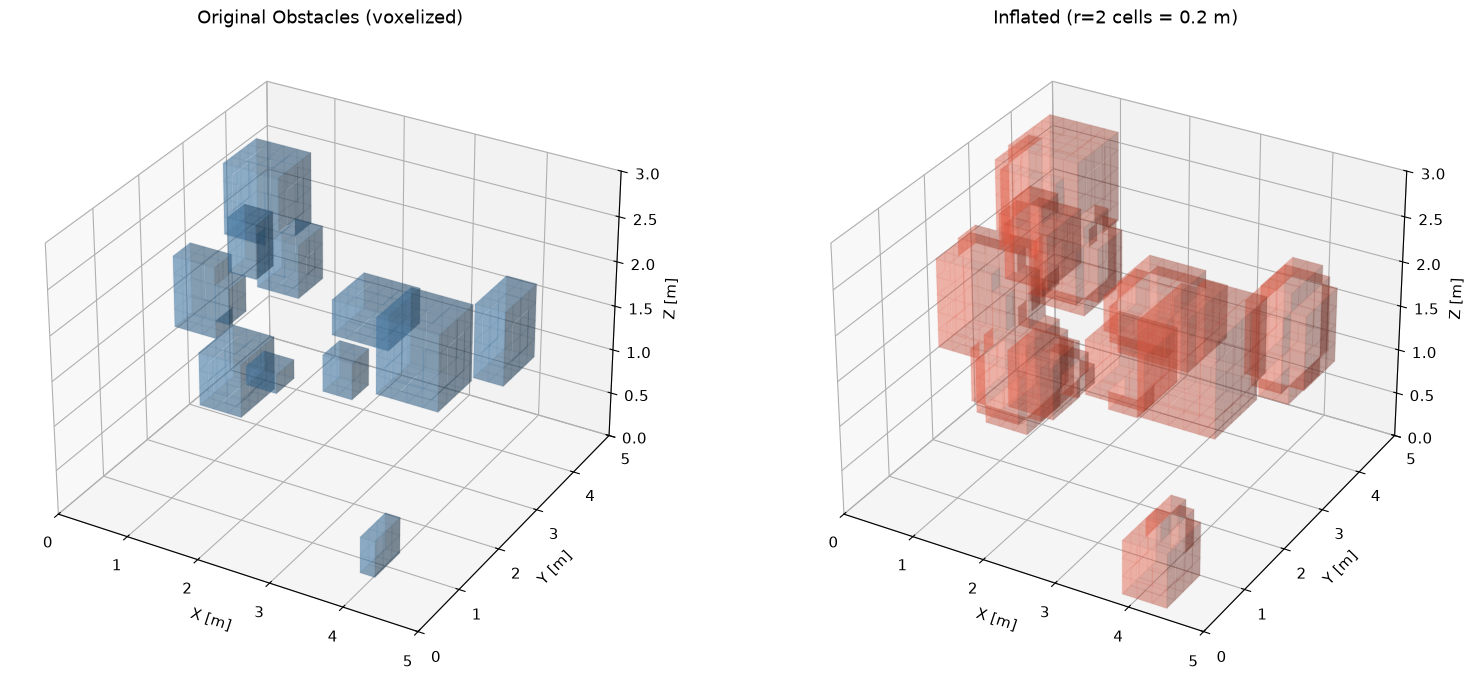

In [2]:
# --- Create a 3D environment with random obstacles ---
grid_shape = (50, 50, 30)
resolution = 0.1  # 10 cm voxels
origin = np.zeros(3)

env = create_random_obstacles(
    grid_shape=grid_shape,
    n_obstacles=12,
    obstacle_size_range=(3, 8),
    resolution=resolution,
    origin=origin,
    seed=42,
)

inflate_cells = 2  # ~0.2 m safety radius
env_inflated = env.inflate(inflate_cells)

occ_orig = np.sum(env.grid)
occ_infl = np.sum(env_inflated.grid)
total = np.prod(grid_shape)
print(f'Grid shape:        {grid_shape}')
print(f'Resolution:        {resolution} m')
print(f'World extent:      {np.array(grid_shape) * resolution} m')
print(f'Occupied (raw):    {occ_orig} / {total} voxels ({100*occ_orig/total:.1f}%)')
print(f'Occupied (inflated): {occ_infl} / {total} voxels ({100*occ_infl/total:.1f}%)')

# --- Visualization helpers (used throughout notebook) ---

def draw_voxel_obstacles(grid_obj, ax, color='red', alpha=0.25, edge_alpha=0.05):
    """Draw occupied voxels as semi-transparent cubes using ax.voxels()."""
    g = grid_obj.grid
    r = grid_obj.resolution
    o = grid_obj.origin
    max_axis_cells = 25
    stride = max(1, max(g.shape) // max_axis_cells)
    display = g[::stride, ::stride, ::stride] if stride > 1 else g
    r_disp = r * stride

    nx, ny, nz = display.shape
    x = o[0] + np.arange(nx + 1) * r_disp
    y = o[1] + np.arange(ny + 1) * r_disp
    z = o[2] + np.arange(nz + 1) * r_disp

    fc = np.full(display.shape + (4,), mcolors.to_rgba(color, alpha=alpha))
    ec = np.full(display.shape + (4,), mcolors.to_rgba(color, alpha=edge_alpha))
    ax.voxels(*np.meshgrid(x, y, z, indexing='ij'), display,
              facecolors=fc, edgecolors=ec)


def setup_3d_axes(ax, grid_obj, title=''):
    """Configure 3D axes with proper limits and labels."""
    extent = np.array(grid_obj.shape) * grid_obj.resolution + grid_obj.origin
    ax.set_xlim(grid_obj.origin[0], extent[0])
    ax.set_ylim(grid_obj.origin[1], extent[1])
    ax.set_zlim(grid_obj.origin[2], extent[2])
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    if title:
        ax.set_title(title)


def add_start_goal(ax, start_pt, goal_pt):
    """Add consistent start (green circle) and goal (red X) markers."""
    ax.scatter(*start_pt, c='limegreen', s=200, marker='o', zorder=10,
               label='Start', edgecolors='darkgreen', linewidths=1.5)
    ax.scatter(*goal_pt, c='red', s=200, marker='X', zorder=10,
               label='Goal', edgecolors='darkred', linewidths=1.5)


# Legacy wrapper so downstream cells keep working during development
def plot_occupancy_grid(grid_obj, title='', ax=None, color='red', alpha=0.25):
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
    draw_voxel_obstacles(grid_obj, ax, color=color, alpha=alpha)
    setup_3d_axes(ax, grid_obj, title=title)
    return ax

# --- 3D visualization: original vs inflated obstacles ---
fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection='3d')
draw_voxel_obstacles(env, ax1, color='steelblue', alpha=0.35)
setup_3d_axes(ax1, env, title='Original Obstacles (voxelized)')

ax2 = fig.add_subplot(122, projection='3d')
draw_voxel_obstacles(env_inflated, ax2, color='tomato', alpha=0.25)
setup_3d_axes(ax2, env_inflated,
              title=f'Inflated (r={inflate_cells} cells = {inflate_cells*resolution:.1f} m)')

plt.tight_layout()
plt.show()

## 2. A* Search in 3D

A\* (Hart, Nilsson & Raphael, 1968) is the gold-standard **optimal graph-search** algorithm.
It maintains an *open list* (priority queue) ordered by

$$
f(n) = g(n) + h(n)
$$

where

- $g(n)$ is the **cost-to-come**: the shortest known path length from the start to node $n$,
- $h(n)$ is the **heuristic**: an estimate of the remaining cost to the goal.

### Admissibility and Consistency

A heuristic is **admissible** if it never overestimates the true cost:

$$
h(n) \leq h^*(n) \quad \forall \, n
$$

It is **consistent** (monotone) if it satisfies the triangle inequality:

$$
h(n) \leq c(n, n') + h(n') \quad \forall \text{ neighbours } n'
$$

The Euclidean distance $h(n) = \|n - n_{\text{goal}}\|_2$ is both admissible and consistent
for grids with unit or diagonal moves, which **guarantees A\* finds the optimal path**.

### Neighbourhood Connectivity

In a 3D grid each voxel can connect to:

| Connectivity | Neighbours | Move costs |
|:---:|:---:|:---|
| **6-connected** | 6 face-adjacent | All cost 1 |
| **18-connected** | 6 + 12 edge-adjacent | Face: 1, Edge: $\sqrt{2}$ |
| **26-connected** | 6 + 12 + 8 vertex-adjacent | Face: 1, Edge: $\sqrt{2}$, Vertex: $\sqrt{3}$ |

Our implementation uses **26-connected** by default (`allow_diagonal=True`),
which produces smoother paths.

### Proof of A* Optimality

> **Theorem (Hart et al., 1968).** If $h$ is admissible, A\* returns the shortest path.
>
> **Proof sketch.** Suppose A\* terminates by expanding the goal with cost $g_{\text{goal}}$.
> Assume for contradiction that there exists a shorter path $P^*$ with cost $g^* < g_{\text{goal}}$.
>
> Let $n$ be the first node on $P^*$ still in the open list when the goal is expanded.
> By admissibility: $f(n) = g(n) + h(n) \leq g(n) + h^*(n) = g^*$.
>
> Since A\* always expands the node with minimum $f$, and it chose to expand the goal
> instead of $n$: $f(\text{goal}) \leq f(n)$.
>
> But $f(\text{goal}) = g_{\text{goal}} + h(\text{goal}) = g_{\text{goal}} + 0 = g_{\text{goal}}$.
>
> So $g_{\text{goal}} \leq f(n) \leq g^*$, contradicting $g^* < g_{\text{goal}}$. $\square$

### Consistency Implies Admissibility

> **Proposition.** If $h$ is consistent, then $h$ is admissible.
>
> **Proof.** Let $n_0 = n, n_1, n_2, \ldots, n_k = n_{\text{goal}}$ be any optimal
> path from $n$ to the goal. Applying the consistency condition repeatedly:
>
> $$h(n_0) \leq c(n_0, n_1) + h(n_1) \leq c(n_0, n_1) + c(n_1, n_2) + h(n_2) \leq \cdots \leq \sum_{i=0}^{k-1} c(n_i, n_{i+1}) + h(n_k)$$
>
> Since $h(n_{\text{goal}}) = 0$ by definition of a heuristic, we obtain
> $h(n) \leq \sum_{i=0}^{k-1} c(n_i, n_{i+1}) = h^*(n)$. $\square$
>
> The converse is **false**: admissible heuristics need not be consistent (though
> in practice most natural heuristics for grid search are both).

### Complexity Analysis

**Worst case.** A\* explores a tree of branching factor $b$ and solution depth $d$,
giving worst-case time $O(b^d)$.  On a 3D grid with 26-connectivity, $b = 26$.
For a $50 \times 50 \times 30$ grid (75 000 voxels), the search space is enormous
without pruning.

**Effective branching factor.** A good heuristic dramatically reduces the *effective*
branching factor $b^*$, defined implicitly by $N_{\text{expanded}} = (b^*)^d$
where $N_{\text{expanded}}$ is the number of nodes A\* actually expands.
A perfect heuristic ($h = h^*$) gives $b^* = 1$ (only nodes on the optimal path
are expanded).  The Euclidean heuristic for 3D grids typically achieves $b^* \approx 1.5$–$3$,
reducing the search space by orders of magnitude compared to blind search ($b^* = 26$).

**With a binary heap**, each expansion costs $O(\log |V|)$, giving total time
$O(|V| \log |V|)$ and $O(|V|)$ space in the worst case.

### Heuristic Comparison for 3D Grids

Three standard heuristics for grid-based path planning, with $\Delta x, \Delta y, \Delta z$
being the absolute coordinate differences to the goal:

| Heuristic | Formula | Admissible? | Tightness |
|:---|:---|:---:|:---|
| **Euclidean** | $\sqrt{\Delta x^2 + \Delta y^2 + \Delta z^2}$ | Yes (26-conn) | Tightest — straight-line lower bound |
| **Octile (Chebyshev-like)** | $(\sqrt{3}-\sqrt{2})\min + (\sqrt{2}-1)\text{mid} + \max$ | Yes (26-conn) | Tighter than Manhattan; matches grid move costs exactly |
| **Manhattan** | $\Delta x + \Delta y + \Delta z$ | Only for 6-conn | *Over*estimates for diagonal grids → **inadmissible** for 26-connected |

where $\min, \text{mid}, \max$ are the sorted values of $\{\Delta x, \Delta y, \Delta z\}$.

**Which is tightest?** For 26-connected 3D grids, the **octile heuristic** is the
tightest admissible heuristic among the three: it exactly computes the shortest
grid-move distance *in the absence of obstacles*, making $h(n) = h^*(n)$ in free
space.  The Euclidean heuristic is always a lower bound on the octile distance
(since grid paths cannot be shorter than straight lines), so it is slightly looser
but still admissible.  Manhattan distance *overestimates* for 26-connected grids
(it ignores diagonal shortcuts), making it **inadmissible and unsafe** in that setting.

### Relationship: A\* and Dijkstra's Algorithm

Setting $h(n) = 0$ for all nodes makes A\* degenerate to **Dijkstra's algorithm**.
This is trivially admissible ($0 \leq h^*(n)$) and consistent, so optimality
is preserved — but all heuristic guidance is lost.

| Property | Dijkstra ($h = 0$) | A\* (informed $h$) |
|:---|:---|:---|
| Explores | All reachable nodes within cost radius | Only nodes with $f(n) \leq f^*$ |
| Search pattern | Expanding sphere | Directed ellipse toward goal |
| Time (practice) | $O(|V| \log |V|)$ — touches most of the grid | Often 5–50× fewer expansions |
| Optimality | Always | If $h$ is admissible |

Dijkstra is useful as a **baseline**: if A\* and Dijkstra return the same path length
but A\* expands far fewer nodes, the heuristic is doing its job.

Start (world): [0.3 0.3 1. ]   grid: (np.int64(2), np.int64(2), np.int64(10))
Goal  (world): [4.5 4.5 2. ]   grid: (np.int64(45), np.int64(45), np.int64(20))
Free at start: True
Free at goal:  True



A* Results:
  Path found:        Yes
  Waypoints:         44
  Path length:       6.399 m
  Straight-line:     6.023 m
  Length ratio:      1.062
  Min clearance:     0.539 m
  Compute time:      262.8 ms


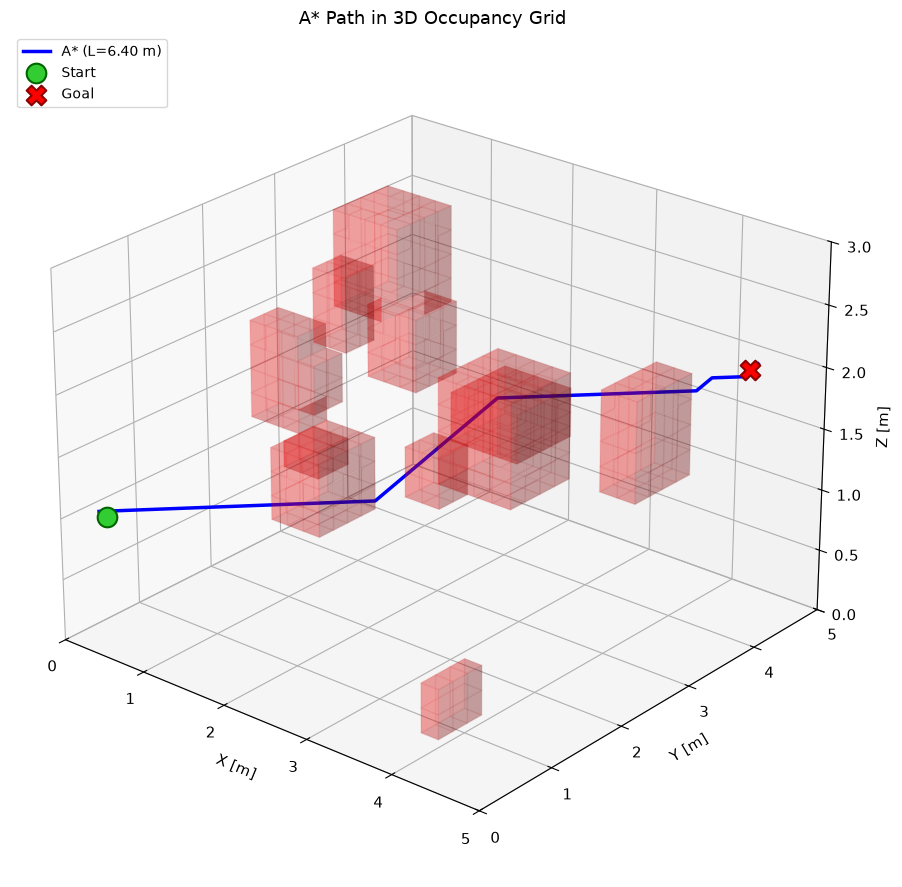

In [3]:
# --- Define start and goal (world coordinates) ---
start = np.array([0.3, 0.3, 1.0])
goal  = np.array([4.5, 4.5, 2.0])

print('Start (world):', start, '  grid:', env_inflated.world_to_grid(start))
print('Goal  (world):', goal,  '  grid:', env_inflated.world_to_grid(goal))
print('Free at start:', env_inflated.is_free(env_inflated.world_to_grid(start)))
print('Free at goal: ', env_inflated.is_free(env_inflated.world_to_grid(goal)))

# --- Run A* ---
t0 = time.perf_counter()
path_astar = astar_3d(env_inflated, start, goal, allow_diagonal=True)
dt_astar = time.perf_counter() - t0

if path_astar is not None:
    length_astar = path_length(path_astar)
    clearance_astar = path_clearance(path_astar, env)
    straight = np.linalg.norm(goal - start)
    print(f'\nA* Results:')
    print(f'  Path found:        Yes')
    print(f'  Waypoints:         {len(path_astar)}')
    print(f'  Path length:       {length_astar:.3f} m')
    print(f'  Straight-line:     {straight:.3f} m')
    print(f'  Length ratio:      {length_astar/straight:.3f}')
    print(f'  Min clearance:     {clearance_astar:.3f} m')
    print(f'  Compute time:      {dt_astar*1000:.1f} ms')
else:
    print('A* found no path!')

# --- Visualize A* path with voxelized obstacles ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
draw_voxel_obstacles(env, ax, color='red', alpha=0.2)
if path_astar is not None:
    ax.plot(path_astar[:, 0], path_astar[:, 1], path_astar[:, 2],
            'b-', linewidth=2.5, label=f'A* (L={length_astar:.2f} m)', zorder=5)
add_start_goal(ax, start, goal)
setup_3d_axes(ax, env, title='A* Path in 3D Occupancy Grid')
ax.legend(fontsize=10, loc='upper left')
ax.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

In [4]:
# ── A* Runtime Assertions ─────────────────────────────────────────────

assert path_astar is not None, "A* must find a path in this environment"
assert len(path_astar) >= 2, "Path must have at least start and goal"

# Path avoids all obstacles (inflated grid)
for i, pt in enumerate(path_astar):
    idx = env_inflated.world_to_grid(pt)
    assert env_inflated.is_free(idx), f"A* path waypoint {i} at {pt} is inside an obstacle"

# Path length is reasonable: between straight-line and a generous upper bound
straight_line_dist = np.linalg.norm(goal - start)
assert length_astar >= straight_line_dist - 1e-6, \
    f"Path length {length_astar:.4f} < straight-line {straight_line_dist:.4f} (impossible)"
assert length_astar < straight_line_dist * 5, \
    f"Path length {length_astar:.4f} > 5× straight-line — suspiciously long"

# All coordinates are finite
assert np.all(np.isfinite(path_astar)), "A* path contains NaN or Inf"

# Start and goal proximity
assert np.linalg.norm(path_astar[0] - start) < 0.2, "Path does not start near the start point"
assert np.linalg.norm(path_astar[-1] - goal) < 0.2, "Path does not end near the goal"

# Clearance must be non-negative
assert clearance_astar >= 0, f"Negative clearance {clearance_astar}"

print("✓ All A* assertions passed")

✓ All A* assertions passed


### A* Admissibility: Why Euclidean Distance Works in 3D Grids

The evaluation function used by A* is:

$$
f(n) = g(n) + h(n)
$$

where $g(n)$ is the exact cost-to-come and $h(n)$ is the heuristic estimate of cost-to-go.

**Admissibility condition.** A heuristic $h$ is *admissible* if:

$$
h(n) \leq h^*(n) \quad \forall\, n
$$

where $h^*(n)$ is the true shortest-path cost from $n$ to the goal.

**Why Euclidean distance is admissible.** In a 3D grid with unit, diagonal ($\sqrt{2}$),
and vertex-diagonal ($\sqrt{3}$) moves, the shortest possible path between any two
points is the straight-line (Euclidean) distance $\|\mathbf{n} - \mathbf{n}_{\text{goal}}\|_2$.
No sequence of grid moves can be shorter than the Euclidean distance, because grid
moves are constrained to lattice directions while the Euclidean distance is the
infimum over all continuous paths.

**Consistency (monotone heuristic).** The Euclidean heuristic also satisfies the
triangle inequality:

$$
h(n) \leq c(n, n') + h(n') \quad \forall\, \text{neighbours } n'
$$

*Proof:* By the triangle inequality of the Euclidean norm,
$\|n - g\| \leq \|n - n'\| + \|n' - g\|$.
The move cost $c(n, n') = \|n - n'\|_2$ (in world units), so
$h(n) = \|n - g\| \leq c(n, n') + \|n' - g\| = c(n, n') + h(n')$. $\square$

Consistency implies admissibility, and additionally guarantees that A* never
re-expands a node — each node is expanded at most once, giving optimal $O(|V| \log |V|)$
complexity.

## 3. Rapidly-exploring Random Trees (RRT)

RRT (LaValle, 1998) is a **sampling-based** planner that builds a tree rooted at the start
by repeatedly sampling random configurations and extending the tree toward them.

### Algorithm

```
T ← {q_start}
for i = 1 to N:
    q_rand ← SAMPLE()            # with prob p_goal, use q_goal
    q_near ← NEAREST(T, q_rand)  # nearest node in tree
    q_new  ← STEER(q_near, q_rand, η)  # move η toward q_rand
    if COLLISION_FREE(q_near, q_new):
        T ← T ∪ {q_new}; add edge (q_near, q_new)
        if ‖q_new − q_goal‖ < ε:
            return PATH(q_start → q_new → q_goal)
return FAILURE
```

Key points:

1. **Random sampling** $q_{\text{rand}}$: uniform in the workspace, with **goal bias**
   (probability $p_{\text{goal}}$ of sampling the goal directly). Typical $p_{\text{goal}} \approx 0.05$–$0.15$.

2. **Nearest neighbour** $q_{\text{near}}$: the tree node closest to $q_{\text{rand}}$ in Euclidean distance.

3. **Steer**: move from $q_{\text{near}}$ toward $q_{\text{rand}}$ by at most step size $\eta$:
   $$q_{\text{new}} = q_{\text{near}} + \min(\eta, \|q_{\text{rand}} - q_{\text{near}}\|) \cdot \frac{q_{\text{rand}} - q_{\text{near}}}{\|q_{\text{rand}} - q_{\text{near}}\|}$$

4. **Collision check**: sample points along the segment $[q_{\text{near}}, q_{\text{new}}]$ and
   verify each is in free space.

5. **Goal check**: if the new node is within threshold $\varepsilon$ of the goal, success.

### Probabilistic Completeness

RRT is **probabilistically complete**: if a feasible path exists, the probability
of finding it approaches 1 as the number of iterations $\to \infty$. However,
the path returned is *not* optimal — it will be jagged and suboptimal.

RRT Results:
  Path found:        Yes
  Waypoints:         28
  Path length:       7.955 m
  Length ratio:      1.321
  Min clearance:     0.257 m
  Compute time:      27.1 ms


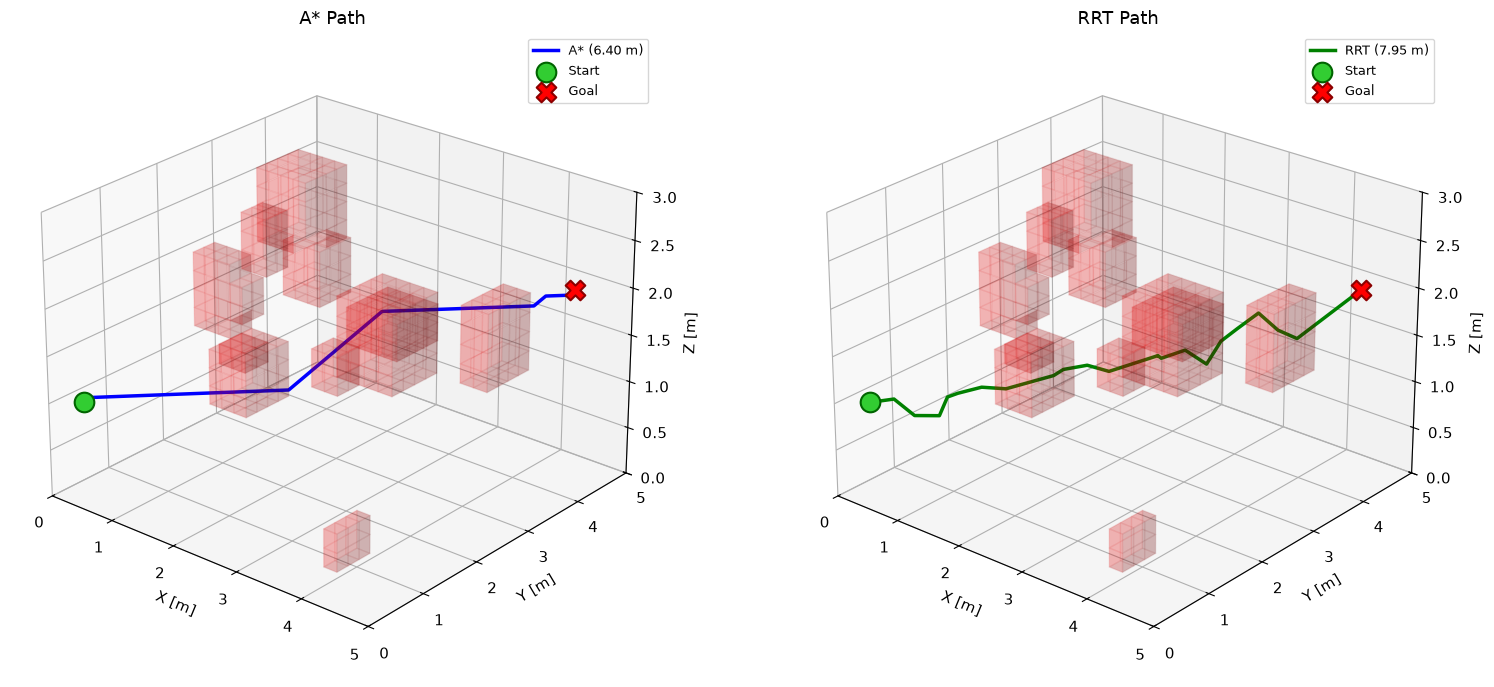


A* vs RRT comparison:
  A* length:  6.399 m   |   RRT length:  7.955 m
  A* time:    262.8 ms    |   RRT time:    27.1 ms
  RRT path is 1.2x the A* path length


In [5]:
# --- Run RRT ---
t0 = time.perf_counter()
path_rrt = rrt(
    env_inflated, start, goal,
    max_iterations=8000,
    step_size=0.3,
    goal_threshold=0.3,
    goal_bias=0.1,
    seed=42,
)
dt_rrt = time.perf_counter() - t0

if path_rrt is not None:
    length_rrt = path_length(path_rrt)
    clearance_rrt = path_clearance(path_rrt, env)
    print(f'RRT Results:')
    print(f'  Path found:        Yes')
    print(f'  Waypoints:         {len(path_rrt)}')
    print(f'  Path length:       {length_rrt:.3f} m')
    print(f'  Length ratio:      {length_rrt/np.linalg.norm(goal-start):.3f}')
    print(f'  Min clearance:     {clearance_rrt:.3f} m')
    print(f'  Compute time:      {dt_rrt*1000:.1f} ms')
else:
    print('RRT found no path!')

# --- Compare A* and RRT side by side ---
fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection='3d')
draw_voxel_obstacles(env, ax1, color='red', alpha=0.15)
if path_astar is not None:
    ax1.plot(path_astar[:, 0], path_astar[:, 1], path_astar[:, 2],
             'b-', linewidth=2.5, label=f'A* ({length_astar:.2f} m)', zorder=5)
add_start_goal(ax1, start, goal)
setup_3d_axes(ax1, env, title='A* Path')
ax1.legend(fontsize=9)
ax1.view_init(elev=25, azim=-50)

ax2 = fig.add_subplot(122, projection='3d')
draw_voxel_obstacles(env, ax2, color='red', alpha=0.15)
if path_rrt is not None:
    ax2.plot(path_rrt[:, 0], path_rrt[:, 1], path_rrt[:, 2],
             'g-', linewidth=2.5, label=f'RRT ({length_rrt:.2f} m)', zorder=5)
add_start_goal(ax2, start, goal)
setup_3d_axes(ax2, env, title='RRT Path')
ax2.legend(fontsize=9)
ax2.view_init(elev=25, azim=-50)

plt.tight_layout()
plt.show()

if path_astar is not None and path_rrt is not None:
    print(f'\nA* vs RRT comparison:')
    print(f'  A* length:  {length_astar:.3f} m   |   RRT length:  {length_rrt:.3f} m')
    print(f'  A* time:    {dt_astar*1000:.1f} ms    |   RRT time:    {dt_rrt*1000:.1f} ms')
    print(f'  RRT path is {length_rrt/length_astar:.1f}x the A* path length')

In [6]:
# ── RRT Runtime Assertions ────────────────────────────────────────────

assert path_rrt is not None, "RRT must find a path in this environment"
assert len(path_rrt) >= 2, "RRT path must have at least 2 waypoints"
assert np.all(np.isfinite(path_rrt)), "RRT path contains NaN or Inf"

# Verify collision-free: every waypoint should be in free space of the inflated grid
for i, pt in enumerate(path_rrt):
    assert env_inflated.is_free_world(pt), \
        f"RRT waypoint {i} at {pt} collides with inflated obstacle"

# RRT path must connect start to goal (within threshold)
assert np.linalg.norm(path_rrt[0] - start) < 0.5, \
    f"RRT path start {path_rrt[0]} too far from start {start}"
assert np.linalg.norm(path_rrt[-1] - goal) < 0.5, \
    f"RRT path end {path_rrt[-1]} too far from goal {goal}"

print("✓ All RRT assertions passed")

✓ All RRT assertions passed


## 4. RRT* — Asymptotically Optimal Planning

RRT\* (Karaman & Frazzoli, IJRR 2011) addresses the key weakness of RRT:
it produces **asymptotically optimal** paths by adding two simple operations.

### Two Key Additions

**1. Choose parent:** When a new node $q_{\text{new}}$ is created, instead of always
parenting it to the nearest node, search all tree nodes within a ball of radius $r_n$
and pick the parent that **minimises the cost-to-come**:

$$
q_{\text{parent}}^* = \arg\min_{q_i \in \mathcal{N}(q_{\text{new}}, r_n)}
\big[ \text{cost}(q_i) + \|q_i - q_{\text{new}}\| \big]
$$

subject to the connecting segment being collision-free.

**2. Rewire:** After adding $q_{\text{new}}$, check every neighbour in the ball.
If routing through $q_{\text{new}}$ yields a **lower cost**, rewire that neighbour's
parent to $q_{\text{new}}$:

$$
\text{if } \text{cost}(q_{\text{new}}) + \|q_{\text{new}} - q_i\| < \text{cost}(q_i):
\quad q_i.\text{parent} \leftarrow q_{\text{new}}
$$

### Convergence Guarantee

As the number of samples $n \to \infty$, the path cost converges to the optimal cost
with probability 1. The rewire radius is chosen as:

$$
r_n = \gamma \left( \frac{\log n}{n} \right)^{1/d}
$$

where $d = 3$ is the dimension and $\gamma$ is a constant depending on the free-space
volume.

> **Fixed radius in practice**: Our implementation uses a fixed rewire radius (e.g. 1.0 m)
> rather than the shrinking schedule above.  This sacrifices the formal asymptotic-optimality
> guarantee (which requires $r_n \to 0$ at the prescribed rate), but for moderate problem
> sizes ($n < 10^4$) the fixed radius is computationally simpler and empirically converges
> to near-optimal paths.  The key intuition for *why* rewiring leads toward the global
> optimum: each new sample gives the algorithm a chance to discover a shortcut through
> previously unexplored space.  Over time, the cumulative effect of these local
> improvements cascades backward through the tree, progressively lowering the cost
> of every path from the root.

### Voronoi Bias: Why RRT Naturally Explores

A remarkable property of RRT is its **Voronoi bias**: the tree automatically expands
toward large unexplored regions of the configuration space. Here is why:

- Each tree node $q_i$ has an implicit **Voronoi region** $V_i$ — the set of all
  points in $\mathcal{C}_{\text{free}}$ for which $q_i$ is the nearest tree node.
- When a random sample $q_{\text{rand}}$ is drawn uniformly, the probability that
  $q_i$ is selected as the nearest node equals $\Pr[q_i \text{ selected}] = \mu(V_i) / \mu(\mathcal{C}_{\text{free}})$, where $\mu(\cdot)$ is the Lebesgue measure (volume).
- Nodes on the **frontier** of the tree, far from other nodes, have the *largest*
  Voronoi regions and therefore the *highest* probability of being selected for
  extension.

This means RRT is naturally biased toward expanding into the largest unexplored voids,
achieving rapid exploration without any explicit frontier management. This property
is central to the probabilistic completeness proof: every open region of free space
will eventually be reached.

### The Key Difference: RRT vs RRT\*

| Property | RRT | RRT\* |
|:---|:---|:---|
| Extends toward random sample | Yes | Yes |
| Chooses best parent in neighbourhood | No (always nearest) | **Yes** (minimum cost-to-come) |
| **Rewires** existing nodes through new node | **No** | **Yes** — this is the critical step |
| Path quality | Suboptimal, jagged | **Asymptotically optimal** |
| Per-iteration cost | $O(\log n)$ with KD-tree | $O(n^{(d-1)/d} \log n)$ due to neighbour search |

The **rewiring step** is what separates RRT\* from RRT. Without rewiring, the tree
topology is frozen once edges are added — early "mistakes" (suboptimal parent choices)
can never be corrected. With rewiring, the tree continuously improves: each new
sample $q_{\text{new}}$ can serve as a relay that shortcuts existing paths, and
the optimal rewire radius $r_n = \gamma \left(\frac{\log n}{n}\right)^{1/d}$ ensures
that enough neighbours are checked to guarantee convergence while keeping computational
cost manageable.

### Informed RRT\* (Gammell, Srinivasa & Barfoot, 2014)

Standard RRT\* continues sampling uniformly even after finding an initial solution,
wasting many samples in regions that cannot possibly improve the current best path.
**Informed RRT\*** restricts sampling to the **informed set** — an ellipsoidal region
defined by the current best cost $c_{\text{best}}$:

$$
\mathcal{X}_{\text{informed}} = \left\{ \mathbf{x} \in \mathcal{C}_{\text{free}} \;\middle|\;
\|\mathbf{x} - \mathbf{x}_{\text{start}}\| + \|\mathbf{x} - \mathbf{x}_{\text{goal}}\| \leq c_{\text{best}} \right\}
$$

This is a **prolate hyperellipsoid** with foci at the start and goal. As the solution
improves, the ellipsoid shrinks, concentrating samples where they can actually help.

**Key properties:**
- Before finding the first solution, Informed RRT\* behaves identically to RRT\*
- After each cost improvement, the sampling domain shrinks automatically
- Convergence rate to the optimum is dramatically faster: empirically 2–10× fewer
  samples needed to reach near-optimal cost
- The approach is orthogonal to other improvements (batch sampling, rejection-free
  sampling) and composes well with them

RRT* (5000 iters): length = 6.070 m, time = 13049 ms, tree nodes = 4062


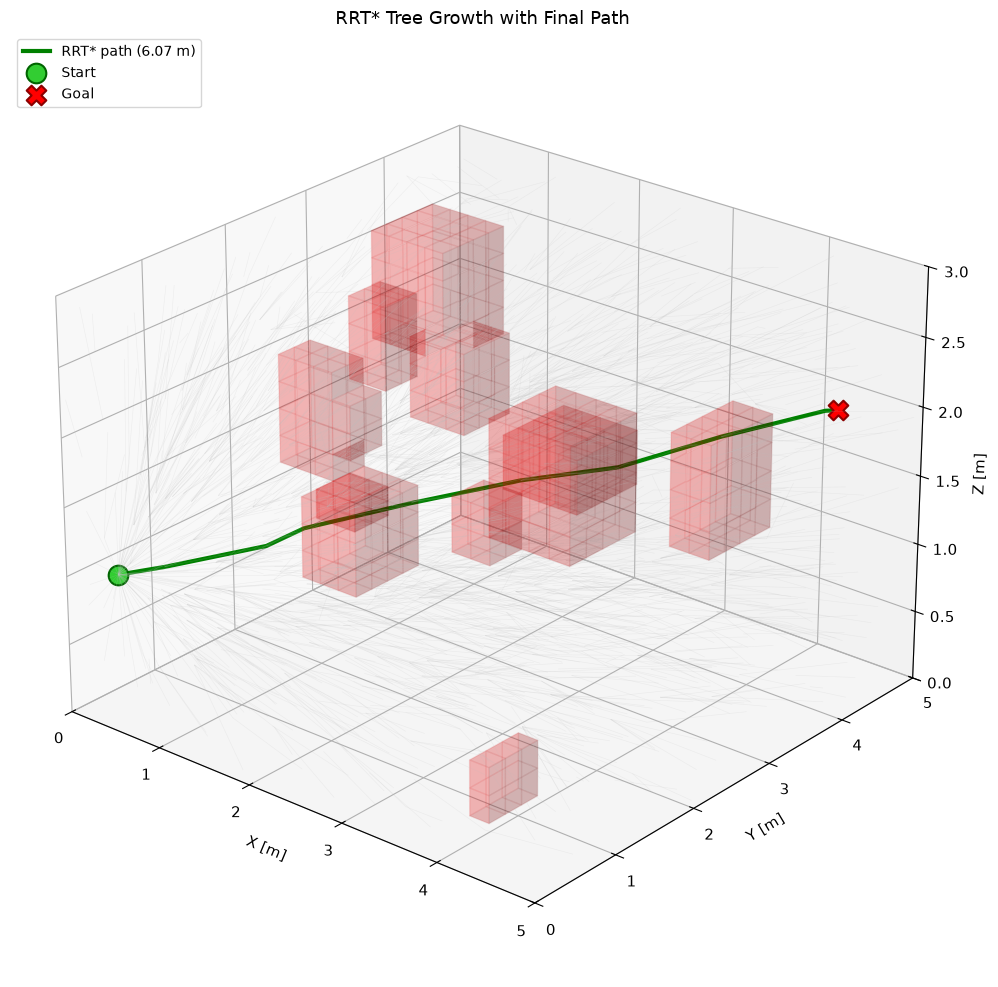

RRT* ( 1000 iters): length = 6.318 m, clearance = 0.437 m, time = 269 ms


RRT* ( 3000 iters): length = 6.097 m, clearance = 0.540 m, time = 2592 ms


RRT* ( 5000 iters): length = 6.070 m, clearance = 0.540 m, time = 6363 ms


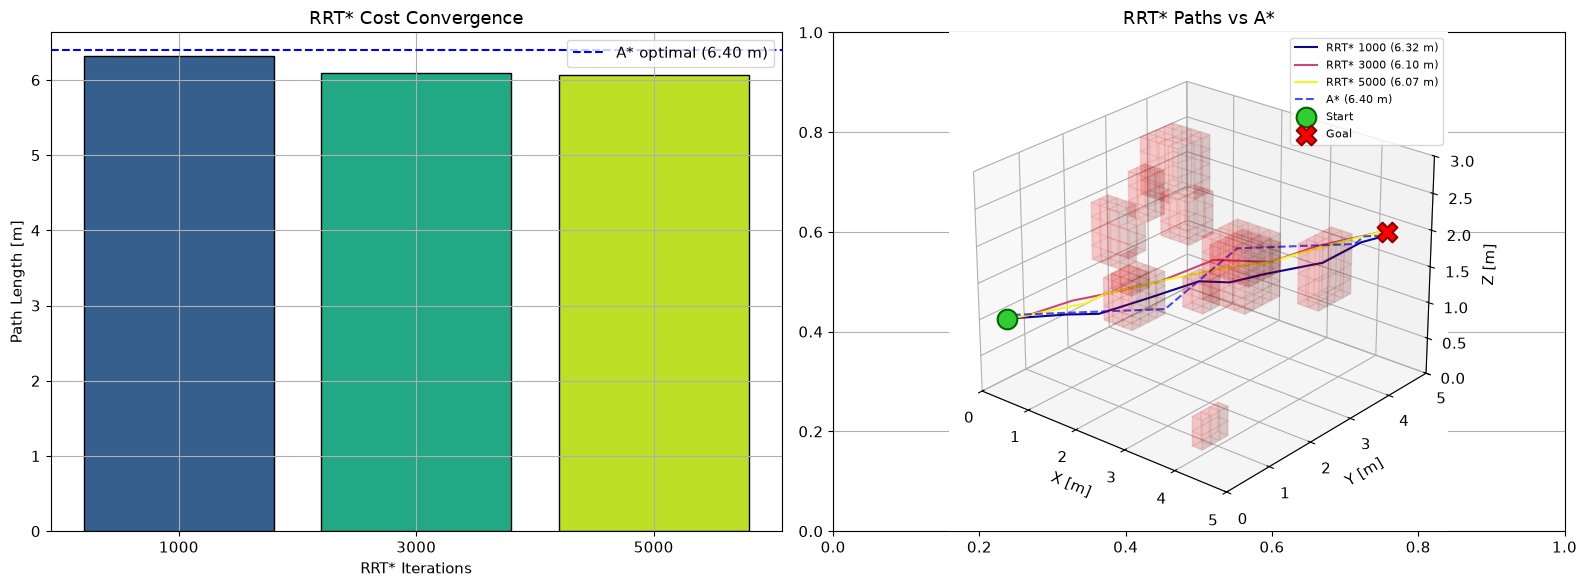

In [7]:
# --- RRT* with tree capture for visualization ---
from src.path_planning import RRTNode, _collision_free_segment

def rrt_star_with_tree(grid, start, goal, max_iterations=5000,
                       step_size=0.3, goal_threshold=0.4,
                       goal_bias=0.1, rewire_radius=1.0, seed=42):
    """RRT* that also returns the full tree for visualization."""
    rng = np.random.RandomState(seed)
    lo, hi = grid.origin, grid.origin + np.array(grid.shape) * grid.resolution
    nodes = [RRTNode(start.copy())]
    best_goal_idx, best_goal_cost = None, float('inf')

    for _ in range(max_iterations):
        q_rand = goal.copy() if rng.rand() < goal_bias else lo + rng.rand(3) * (hi - lo)
        positions = np.array([n.position for n in nodes])
        near_idx = int(np.argmin(np.linalg.norm(positions - q_rand, axis=1)))
        q_near = nodes[near_idx].position
        d = q_rand - q_near
        dist = np.linalg.norm(d)
        if dist < 1e-8:
            continue
        q_new = q_near + min(step_size, dist) * (d / dist)
        if not _collision_free_segment(grid, q_near, q_new, step_size * 0.5):
            continue
        dists_new = np.linalg.norm(positions - q_new, axis=1)
        nbrs = np.where(dists_new < rewire_radius)[0]
        best_parent = near_idx
        best_cost = nodes[near_idx].cost + np.linalg.norm(q_new - q_near)
        for ni in nbrs:
            c = nodes[ni].cost + np.linalg.norm(q_new - nodes[ni].position)
            if c < best_cost and _collision_free_segment(grid, nodes[ni].position, q_new, step_size * 0.5):
                best_parent, best_cost = ni, c
        new_idx = len(nodes)
        nodes.append(RRTNode(q_new, parent=best_parent, cost=best_cost))
        for ni in nbrs:
            c = best_cost + np.linalg.norm(nodes[ni].position - q_new)
            if c < nodes[ni].cost and _collision_free_segment(grid, q_new, nodes[ni].position, step_size * 0.5):
                nodes[ni].parent, nodes[ni].cost = new_idx, c
        dg = np.linalg.norm(q_new - goal)
        if dg < goal_threshold and best_cost + dg < best_goal_cost:
            best_goal_cost = best_cost + dg
            best_goal_idx = new_idx

    path = None
    if best_goal_idx is not None:
        path = [goal]
        idx = best_goal_idx
        while idx is not None:
            path.append(nodes[idx].position)
            idx = nodes[idx].parent
        path.reverse()
        path = np.array(path)
    return path, nodes

# --- Run RRT* with tree capture ---
t0 = time.perf_counter()
path_rrt_star_best, tree_nodes = rrt_star_with_tree(
    env_inflated, start, goal, max_iterations=5000,
    step_size=0.3, goal_threshold=0.4, goal_bias=0.1,
    rewire_radius=1.0, seed=42,
)
dt_rrt_star = time.perf_counter() - t0

if path_rrt_star_best is not None:
    print(f'RRT* (5000 iters): length = {path_length(path_rrt_star_best):.3f} m, '
          f'time = {dt_rrt_star*1000:.0f} ms, tree nodes = {len(tree_nodes)}')

# --- Visualize RRT* tree growth + final path ---
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
draw_voxel_obstacles(env, ax, color='red', alpha=0.15)

edges = []
for i in range(1, len(tree_nodes)):
    n = tree_nodes[i]
    if n.parent is not None:
        edges.append([n.position.tolist(), tree_nodes[n.parent].position.tolist()])

max_disp = 2000
if len(edges) > max_disp:
    sel = np.random.RandomState(0).choice(len(edges), max_disp, replace=False)
    edges_disp = [edges[i] for i in sel]
else:
    edges_disp = edges

lc = Line3DCollection(edges_disp, colors='silver', alpha=0.2, linewidths=0.4)
ax.add_collection3d(lc)

if path_rrt_star_best is not None:
    ax.plot(path_rrt_star_best[:, 0], path_rrt_star_best[:, 1], path_rrt_star_best[:, 2],
            'g-', linewidth=3, label=f'RRT* path ({path_length(path_rrt_star_best):.2f} m)', zorder=5)
add_start_goal(ax, start, goal)
setup_3d_axes(ax, env, title='RRT* Tree Growth with Final Path')
ax.legend(fontsize=10, loc='upper left')
ax.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

# --- RRT* convergence comparison ---
iteration_counts = [1000, 3000, 5000]
rrt_star_results = {}

for n_iter in iteration_counts:
    t0 = time.perf_counter()
    path = rrt_star(
        env_inflated, start, goal,
        max_iterations=n_iter, step_size=0.3,
        goal_threshold=0.4, goal_bias=0.1,
        rewire_radius=1.0, seed=42,
    )
    dt = time.perf_counter() - t0
    if path is not None:
        pl = path_length(path)
        pc = path_clearance(path, env)
        rrt_star_results[n_iter] = {'path': path, 'length': pl, 'clearance': pc, 'time': dt}
        print(f'RRT* ({n_iter:5d} iters): length = {pl:.3f} m, clearance = {pc:.3f} m, time = {dt*1000:.0f} ms')
    else:
        rrt_star_results[n_iter] = None
        print(f'RRT* ({n_iter:5d} iters): no path found, time = {dt*1000:.0f} ms')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

found_iters = [n for n, r in rrt_star_results.items() if r is not None]
found_lengths = [rrt_star_results[n]['length'] for n in found_iters]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(found_iters)))
axes[0].bar([str(n) for n in found_iters], found_lengths, color=colors, edgecolor='black')
if path_astar is not None:
    axes[0].axhline(length_astar, color='blue', linestyle='--', linewidth=1.5,
                    label=f'A* optimal ({length_astar:.2f} m)')
axes[0].set_xlabel('RRT* Iterations')
axes[0].set_ylabel('Path Length [m]')
axes[0].set_title('RRT* Cost Convergence')
axes[0].legend()

ax3d = fig.add_subplot(122, projection='3d')
draw_voxel_obstacles(env, ax3d, color='red', alpha=0.1)
cmap = plt.cm.plasma
for i, n_iter in enumerate(found_iters):
    p = rrt_star_results[n_iter]['path']
    c = cmap(i / max(len(found_iters)-1, 1))
    ax3d.plot(p[:, 0], p[:, 1], p[:, 2], '-', color=c, linewidth=1.5,
             label=f'RRT* {n_iter} ({rrt_star_results[n_iter]["length"]:.2f} m)')
if path_astar is not None:
    ax3d.plot(path_astar[:, 0], path_astar[:, 1], path_astar[:, 2],
             'b--', linewidth=1.5, alpha=0.7, label=f'A* ({length_astar:.2f} m)')
add_start_goal(ax3d, start, goal)
setup_3d_axes(ax3d, env, title='RRT* Paths vs A*')
ax3d.legend(fontsize=8)
ax3d.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

In [8]:
# ── RRT* Runtime Assertions ───────────────────────────────────────────

assert path_rrt_star_best is not None, "RRT* must find a path"
assert np.all(np.isfinite(path_rrt_star_best)), "RRT* path contains NaN or Inf"

# RRT* path length must be positive
length_rrt_star = path_length(path_rrt_star_best)
assert length_rrt_star > 0, "RRT* path length must be positive"

# RRT* endpoints
assert np.linalg.norm(path_rrt_star_best[0] - start) < 0.5, \
    "RRT* path doesn't start near start"
assert np.linalg.norm(path_rrt_star_best[-1] - goal) < 0.5, \
    "RRT* path doesn't end near goal"

# All coordinates must be finite
for i, pt in enumerate(path_rrt_star_best):
    assert np.all(np.isfinite(pt)), f"RRT* waypoint {i} contains NaN/Inf"

# Tree nodes must all have finite positions
for i, node in enumerate(tree_nodes):
    assert np.all(np.isfinite(node.position)), \
        f"RRT* tree node {i} has non-finite position"

print("✓ All RRT* assertions passed")

✓ All RRT* assertions passed


## 5. Artificial Potential Fields (APF)

The APF approach (Khatib, 1986) treats the robot as a particle moving under the
influence of an **attractive potential** pulling it toward the goal and a **repulsive
potential** pushing it away from obstacles. The path is found by **gradient descent**
on the total potential.

### Attractive Potential

A simple quadratic attractive potential centred on the goal $\mathbf{q}_g$:

$$
U_{\text{att}}(\mathbf{q}) = \frac{1}{2} k_{\text{att}} \|\mathbf{q} - \mathbf{q}_g\|^2
$$

Its negative gradient gives the attractive force:

$$
\mathbf{F}_{\text{att}}(\mathbf{q}) = -\nabla U_{\text{att}} = -k_{\text{att}}(\mathbf{q} - \mathbf{q}_g)
$$

### Repulsive Potential

Each obstacle exerts a repulsive potential that only activates within influence
distance $d_0$:

$$
U_{\text{rep}}(\mathbf{q}) = \begin{cases}
\frac{1}{2} k_{\text{rep}} \left(\frac{1}{d(\mathbf{q})} - \frac{1}{d_0}\right)^2 & \text{if } d(\mathbf{q}) \leq d_0 \\
0 & \text{otherwise}
\end{cases}
$$

where $d(\mathbf{q})$ is the distance to the nearest obstacle.

**Deriving the repulsive force** via the chain rule (the steps that matter):

1. $\mathbf{F}_{\text{rep}} = -\nabla U_{\text{rep}}$ by definition of a conservative force.
2. Apply the chain rule to $U_{\text{rep}} = \tfrac{1}{2}k_{\text{rep}}(1/d - 1/d_0)^2$:
   $$\nabla U_{\text{rep}} = k_{\text{rep}}\!\left(\frac{1}{d} - \frac{1}{d_0}\right) \nabla\!\left(\frac{1}{d}\right)$$
3. Compute $\nabla(1/d) = -d^{-2}\nabla d$.
4. The gradient of the distance function is $\nabla d(\mathbf{q}) = \hat{\mathbf{n}}$ (unit vector
   pointing **away** from the nearest obstacle).
5. Substituting and absorbing the minus signs:

$$\mathbf{F}_{\text{rep}}(\mathbf{q}) = -\nabla U_{\text{rep}} = k_{\text{rep}} \left(\frac{1}{d(\mathbf{q})} - \frac{1}{d_0}\right) \frac{1}{d(\mathbf{q})^2} \hat{\mathbf{n}}$$

where $\hat{\mathbf{n}}$ is the unit vector pointing away from the nearest obstacle.

### Total Force and Path Generation

The robot follows the total force $\mathbf{F} = \mathbf{F}_{\text{att}} + \mathbf{F}_{\text{rep}}$
using gradient descent with small step size $\alpha$:

$$
\mathbf{q}_{k+1} = \mathbf{q}_k + \alpha \, \frac{\mathbf{F}(\mathbf{q}_k)}{\|\mathbf{F}(\mathbf{q}_k)\|}
$$

### Known Limitation: Local Minima

When the attractive and repulsive forces cancel out **away from the goal**, the planner
gets trapped in a **local minimum**: a configuration $\mathbf{q}^*$ where
$\nabla U(\mathbf{q}^*) = 0$ but $\mathbf{q}^* \neq \mathbf{q}_g$.

**Why does this happen?** The total potential $U = U_{\text{att}} + U_{\text{rep}}$
is a sum of a convex bowl (attractive) and multiple "bumps" (repulsive). Their
superposition can create saddle points and local basins, especially when:
- An obstacle lies **directly between** start and goal (the attractive gradient points
  straight into the repulsive barrier)
- Multiple obstacles create a **concave pocket** — the repulsive forces from the
  pocket walls push inward, trapping the robot
- Narrow corridors produce **opposing repulsive forces** from parallel walls that
  nearly cancel the attractive pull

Since APF is a gradient-descent method, it follows $-\nabla U$ and has **no mechanism**
to escape these local minima. The path simply stalls at $\mathbf{q}^*$.

### Navigation Functions: Guaranteed No Local Minima

**Navigation functions** (Rimon & Koditschek, 1992) are a special class of potential
functions that eliminate local minima by construction. A navigation function
$\varphi : \mathcal{C}_{\text{free}} \to [0, 1]$ satisfies:

1. **Smooth** on $\mathcal{C}_{\text{free}}$
2. **Unique minimum** at the goal: $\varphi(\mathbf{q}_g) = 0$, with no other local minima
3. **Maximum on the boundary**: $\varphi(\mathbf{q}) = 1$ for all $\mathbf{q} \in \partial \mathcal{C}_{\text{free}}$
4. **Morse function**: all critical points are non-degenerate (the Hessian is full rank)

Rimon and Koditschek showed that such functions exist for *sphere worlds* (environments
where obstacles are balls). Their construction uses a carefully tuned ratio:

$$
\varphi(\mathbf{q}) = \frac{d_{\text{goal}}(\mathbf{q})^k}{
\left( d_{\text{goal}}(\mathbf{q})^k + \beta(\mathbf{q}) \right)^{1/k}}
$$

where $d_{\text{goal}}$ is the distance to the goal, $\beta(\mathbf{q})$ encodes
obstacle proximity (product of distances to all obstacle boundaries), and $k$
is a tuning parameter that must be sufficiently large. For large enough $k$, the
only critical point in the interior of $\mathcal{C}_{\text{free}}$ is the goal —
**gradient descent on $\varphi$ is guaranteed to converge from any start**.

The practical limitation: constructing $\varphi$ for complex (non-spherical) obstacle
geometries is difficult, requiring diffeomorphic mappings to sphere worlds.

### Connection to Model Predictive Control

APF can be viewed as a **one-step greedy optimisation**: at each timestep, the robot
moves in the direction that maximally decreases the potential $U$, without considering
future states. This is equivalent to solving:

$$
\mathbf{q}_{k+1} = \arg\min_{\|\mathbf{q} - \mathbf{q}_k\| \leq \alpha} U(\mathbf{q})
$$

**Model Predictive Control (MPC)** generalises this by optimising over a **receding
horizon** of $H$ steps:

$$
\min_{\mathbf{q}_{k+1}, \ldots, \mathbf{q}_{k+H}} \sum_{i=1}^{H} U(\mathbf{q}_{k+i})
+ \text{dynamics constraints}
$$

The key advantage: by looking ahead $H$ steps, MPC can "see around" local minima
that trap the one-step APF. With $H = 1$, MPC reduces exactly to APF. Increasing
$H$ trades computation for global awareness. In practice, combining APF for fast
reactive response with MPC for look-ahead in tricky regions gives the best of both worlds.

APF Results:
  Reached goal:      Yes
  Steps taken:       122
  Path length:       6.119 m
  Final distance:    0.000 m
  Compute time:      216.2 ms


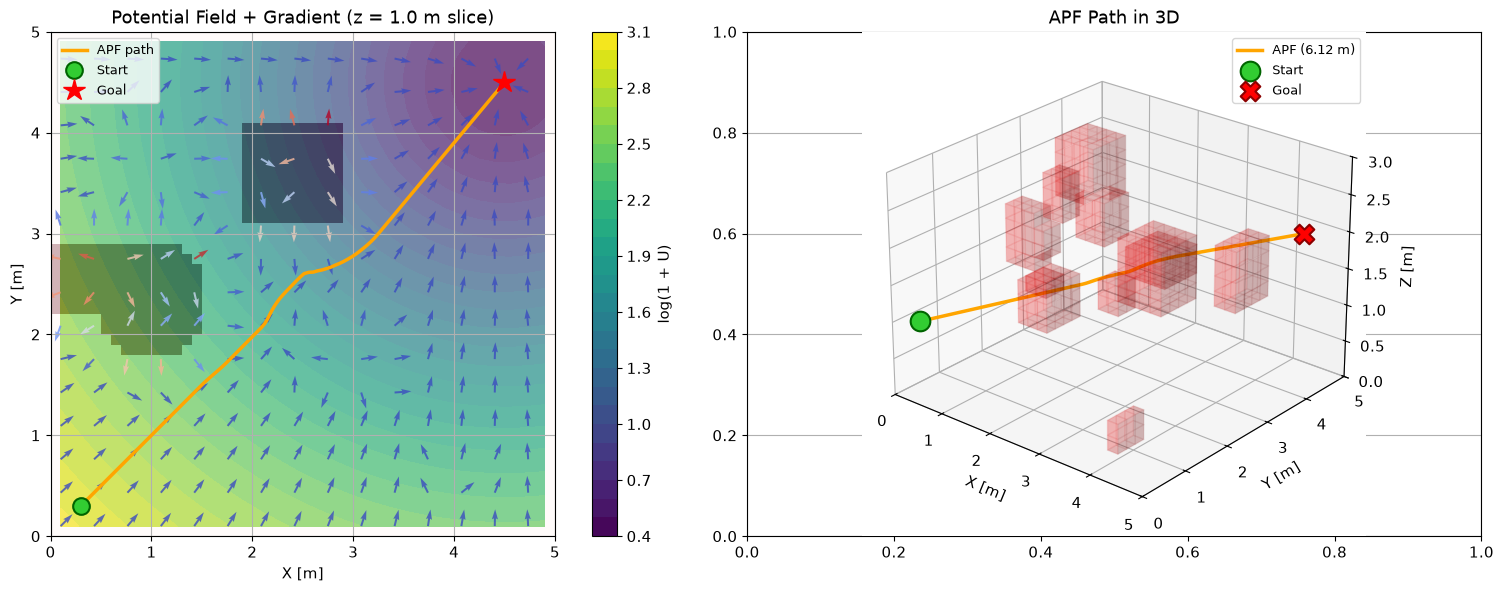

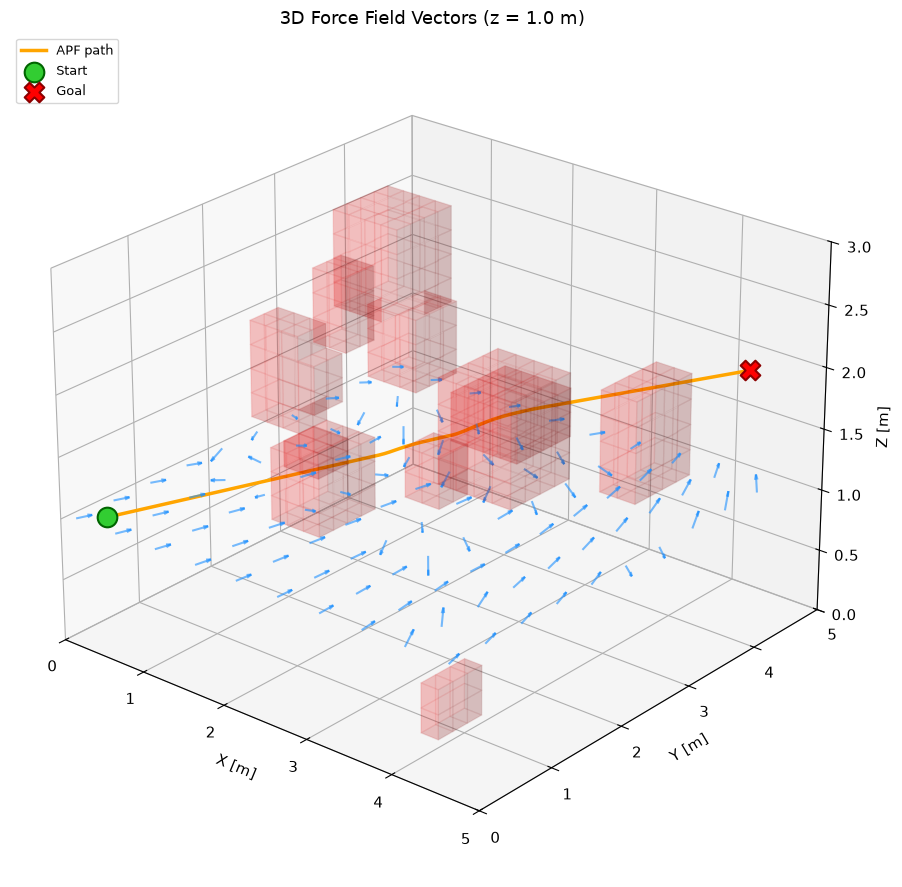


--- Local Minimum Demonstration ---


Final distance to goal: 0.000 m
Trapped in local minimum: No
Steps before stopping: 281


In [9]:
# --- Run APF ---
t0 = time.perf_counter()
path_apf = artificial_potential_field(
    env_inflated, start, goal,
    k_att=1.0, k_rep=0.5, d0=0.5,
    step_size=0.05, max_steps=5000, goal_threshold=0.15,
)
dt_apf = time.perf_counter() - t0

length_apf = path_length(path_apf)
reached_goal = np.linalg.norm(path_apf[-1] - goal) < 0.3

print(f'APF Results:')
print(f'  Reached goal:      {"Yes" if reached_goal else "NO — local minimum!"}')
print(f'  Steps taken:       {len(path_apf)}')
print(f'  Path length:       {length_apf:.3f} m')
print(f'  Final distance:    {np.linalg.norm(path_apf[-1] - goal):.3f} m')
print(f'  Compute time:      {dt_apf*1000:.1f} ms')

# --- Compute potential field on 2D slice for visualization ---
from src.path_planning import _compute_repulsive_force

z_slice_world = 1.0
nx, ny = 30, 30
xs = np.linspace(env_inflated.origin[0] + 0.1,
                 env_inflated.origin[0] + grid_shape[0]*resolution - 0.1, nx)
ys = np.linspace(env_inflated.origin[1] + 0.1,
                 env_inflated.origin[1] + grid_shape[1]*resolution - 0.1, ny)
Xg, Yg = np.meshgrid(xs, ys)

U_total = np.zeros_like(Xg)
Fx, Fy, Fz_slice = np.zeros_like(Xg), np.zeros_like(Xg), np.zeros_like(Xg)

for i in range(nx):
    for j in range(ny):
        q = np.array([Xg[j, i], Yg[j, i], z_slice_world])
        u_att = 0.5 * 1.0 * np.linalg.norm(q - goal)**2
        f_att = -1.0 * (q - goal)
        f_rep = _compute_repulsive_force(env_inflated, q, 0.5, 0.5)
        U_total[j, i] = u_att
        f = f_att + f_rep
        Fx[j, i], Fy[j, i], Fz_slice[j, i] = f[0], f[1], f[2]

# --- Figure 1: 2D potential field slice with gradient arrows + obstacle overlay ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

occ_slice = env_inflated.grid[:, :, int((z_slice_world - env_inflated.origin[2]) / env_inflated.resolution)]
occ_x = np.linspace(env_inflated.origin[0], env_inflated.origin[0] + grid_shape[0]*resolution, occ_slice.shape[0]+1)
occ_y = np.linspace(env_inflated.origin[1], env_inflated.origin[1] + grid_shape[1]*resolution, occ_slice.shape[1]+1)

im = axes[0].contourf(Xg, Yg, np.log1p(U_total), levels=30, cmap='viridis')
plt.colorbar(im, ax=axes[0], label='log(1 + U)')
axes[0].pcolormesh(occ_x, occ_y, occ_slice.T, cmap='Reds', alpha=0.3, shading='flat')

skip = 2
F_mag = np.sqrt(Fx**2 + Fy**2)
F_mag_safe = np.where(F_mag > 0, F_mag, 1.0)
axes[0].quiver(Xg[::skip, ::skip], Yg[::skip, ::skip],
               Fx[::skip, ::skip] / F_mag_safe[::skip, ::skip],
               Fy[::skip, ::skip] / F_mag_safe[::skip, ::skip],
               F_mag[::skip, ::skip], cmap='coolwarm', alpha=0.8, scale=30)
axes[0].plot(path_apf[:, 0], path_apf[:, 1], '-', color='orange', linewidth=2.5, label='APF path')
axes[0].plot(*start[:2], 'o', color='limegreen', markersize=12, markeredgecolor='darkgreen',
             markeredgewidth=1.5, label='Start')
axes[0].plot(*goal[:2], 'r*', markersize=16, label='Goal')
axes[0].set_xlabel('X [m]'); axes[0].set_ylabel('Y [m]')
axes[0].set_title(f'Potential Field + Gradient (z = {z_slice_world} m slice)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_aspect('equal')

# --- 3D APF path with voxel obstacles ---
ax3d = fig.add_subplot(122, projection='3d')
draw_voxel_obstacles(env, ax3d, color='red', alpha=0.15)
ax3d.plot(path_apf[:, 0], path_apf[:, 1], path_apf[:, 2],
          '-', color='orange', linewidth=2.5, label=f'APF ({length_apf:.2f} m)', zorder=5)
add_start_goal(ax3d, start, goal)
setup_3d_axes(ax3d, env, title='APF Path in 3D')
ax3d.legend(fontsize=9)
ax3d.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

# --- Figure 2: 3D gradient field quiver at z-slice ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
draw_voxel_obstacles(env, ax, color='red', alpha=0.12)

skip3 = 3
Zg_flat = np.full_like(Xg, z_slice_world)
ax.quiver(Xg[::skip3, ::skip3], Yg[::skip3, ::skip3], Zg_flat[::skip3, ::skip3],
          Fx[::skip3, ::skip3], Fy[::skip3, ::skip3], Fz_slice[::skip3, ::skip3],
          length=0.15, normalize=True, color='dodgerblue', alpha=0.6, arrow_length_ratio=0.3)
ax.plot(path_apf[:, 0], path_apf[:, 1], path_apf[:, 2],
        '-', color='orange', linewidth=2.5, label='APF path', zorder=5)
add_start_goal(ax, start, goal)
setup_3d_axes(ax, env, title=f'3D Force Field Vectors (z = {z_slice_world} m)')
ax.legend(fontsize=9, loc='upper left')
ax.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

# --- Demonstrate local minimum scenario ---
print('\n--- Local Minimum Demonstration ---')
env_trap = create_random_obstacles(
    grid_shape=(30, 30, 20), n_obstacles=1,
    obstacle_size_range=(10, 15), resolution=0.1,
    origin=np.zeros(3), seed=99,
)
start_trap = np.array([0.3, 1.5, 1.0])
goal_trap = np.array([2.7, 1.5, 1.0])

path_trap = artificial_potential_field(
    env_trap, start_trap, goal_trap,
    k_att=1.0, k_rep=2.0, d0=0.8,
    step_size=0.03, max_steps=3000, goal_threshold=0.15,
)
dist_final = np.linalg.norm(path_trap[-1] - goal_trap)
trapped = dist_final > 0.3
print(f'Final distance to goal: {dist_final:.3f} m')
print(f'Trapped in local minimum: {"YES" if trapped else "No"}')
print(f'Steps before stopping: {len(path_trap)}')

In [10]:
# ── APF Runtime Assertions ────────────────────────────────────────────

assert path_apf is not None and len(path_apf) >= 2, "APF must produce a trajectory"
assert np.all(np.isfinite(path_apf)), "APF path contains NaN or Inf coordinates"

# Path length must be positive and finite
assert np.isfinite(length_apf) and length_apf > 0, \
    f"APF path length must be positive and finite, got {length_apf}"

# Verify force magnitudes are finite at sampled path points
from src.path_planning import _compute_repulsive_force
for i in range(0, len(path_apf), max(1, len(path_apf) // 10)):
    q = path_apf[i]
    f_att = -1.0 * (q - goal)
    f_rep = _compute_repulsive_force(env_inflated, q, 0.5, 0.5)
    f_total = f_att + f_rep
    assert np.all(np.isfinite(f_att)), f"Attractive force at step {i} is NaN/Inf"
    assert np.all(np.isfinite(f_rep)), f"Repulsive force at step {i} is NaN/Inf"
    assert np.all(np.isfinite(f_total)), f"Total force at step {i} is NaN/Inf"
    assert np.linalg.norm(f_att) < 1e6, f"Attractive force magnitude unreasonably large at step {i}"

# Start proximity
assert np.linalg.norm(path_apf[0] - start) < 0.2, "APF path doesn't start near start"

# 2D potential field slice assertions
assert np.all(np.isfinite(U_total)), "Potential field slice contains NaN/Inf"
assert np.all(np.isfinite(Fx)), "Force field Fx contains NaN/Inf"
assert np.all(np.isfinite(Fy)), "Force field Fy contains NaN/Inf"

print("✓ All APF assertions passed")

✓ All APF assertions passed


## 6. Path Smoothing & Post-Processing

Raw paths from grid-based planners (A\*) are jagged, following voxel edges.
Sampling-based paths (RRT) have random kinks. Both need **post-processing**
before they are suitable for flight.

### Shortcut-Based Smoothing

The simplest approach: randomly pick two points $p_i, p_j$ on the path ($i < j$)
and check if the direct line segment is collision-free. If so, remove all
intermediate waypoints $p_{i+1}, \ldots, p_{j-1}$. Repeat for many iterations.

**Collision-free invariant**: The smoothed path is collision-free by construction —
each shortcut is only accepted if the replacement line segment passes the collision
check.  Starting from a collision-free path, every accepted shortcut preserves this
property (proof by induction on the number of accepted shortcuts).

**Limitation**: The collision check tests a finite set of sample points along each
line segment.  If the step size is larger than the thinnest obstacle, a shortcut may
pass through a thin wall undetected.  In practice, the sample step should be
$\leq 0.5 \times \text{resolution}$ to guarantee that no occupied voxel is skipped.

### Uniform Resampling

After smoothing, resample the path at a uniform arc-length spacing $\Delta s$.
This ensures the downstream trajectory generator receives evenly-spaced waypoints,
avoiding velocity spikes in the controller.


A* Smoothing Results:
  Raw:         44 pts, length = 6.399 m, clearance = 0.539 m
  Smoothed:     2 pts, length = 6.163 m, clearance = 1.400 m
  Resampled:   41 pts, length = 6.163 m
  Length reduction: 3.7%



RRT Smoothing Results:
  Raw:         28 pts, length = 7.955 m, clearance = 0.257 m
  Smoothed:     2 pts, length = 6.023 m, clearance = 1.352 m
  Resampled:   40 pts, length = 6.023 m
  Length reduction: 24.3%


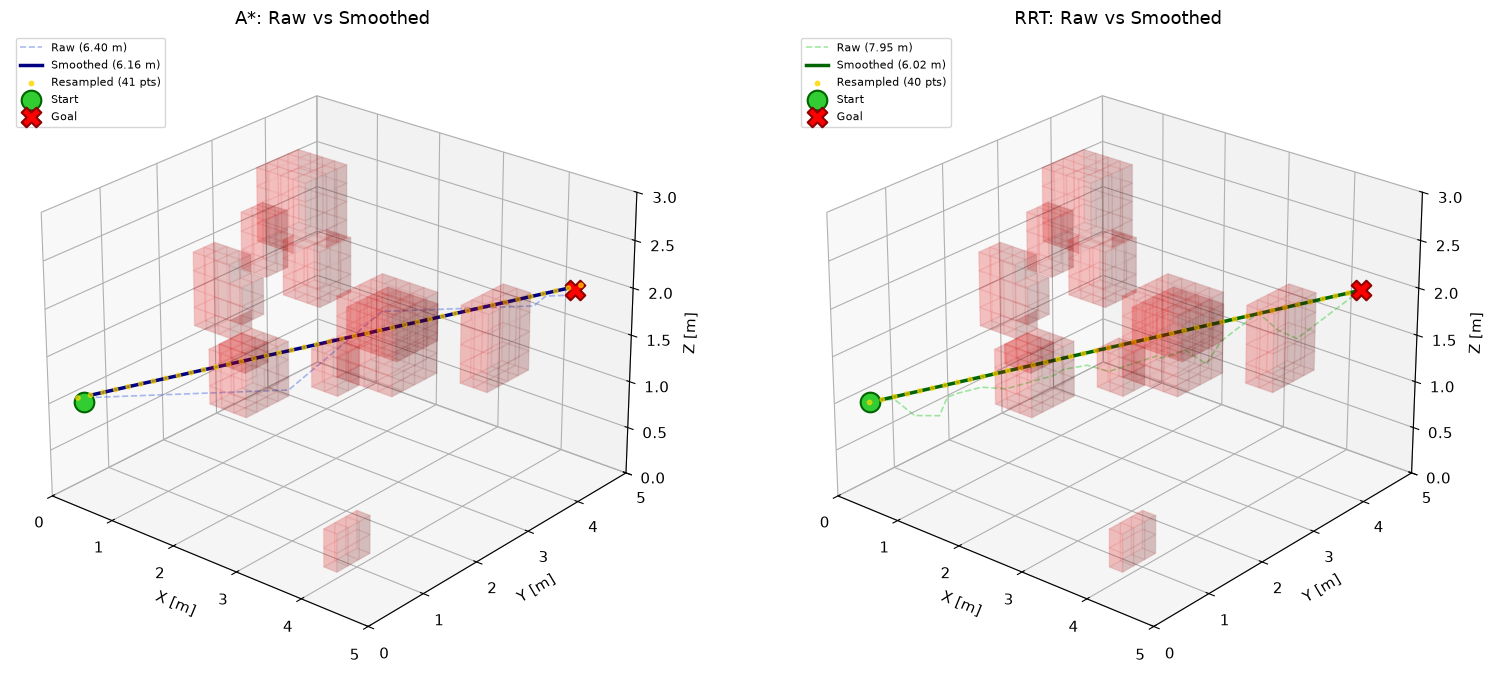

In [11]:
# --- Smooth A* and RRT paths ---
results_smooth = {}

for name, raw_path in [('A*', path_astar), ('RRT', path_rrt)]:
    if raw_path is None:
        print(f'{name}: no path to smooth')
        continue
    smoothed = smooth_path(raw_path, env_inflated, n_iterations=200, seed=42)
    resampled = resample_path(smoothed, spacing=0.15)

    l_raw = path_length(raw_path)
    l_smooth = path_length(smoothed)
    l_resamp = path_length(resampled)
    c_raw = path_clearance(raw_path, env)
    c_smooth = path_clearance(smoothed, env)

    results_smooth[name] = {
        'raw': raw_path, 'smoothed': smoothed, 'resampled': resampled,
        'l_raw': l_raw, 'l_smooth': l_smooth, 'l_resamp': l_resamp,
        'c_raw': c_raw, 'c_smooth': c_smooth,
    }

    print(f'\n{name} Smoothing Results:')
    print(f'  Raw:       {len(raw_path):4d} pts, length = {l_raw:.3f} m, clearance = {c_raw:.3f} m')
    print(f'  Smoothed:  {len(smoothed):4d} pts, length = {l_smooth:.3f} m, clearance = {c_smooth:.3f} m')
    print(f'  Resampled: {len(resampled):4d} pts, length = {l_resamp:.3f} m')
    print(f'  Length reduction: {100*(1 - l_smooth/l_raw):.1f}%')

# --- Visualize before/after smoothing with voxel obstacles ---
path_colors = {'A*': ('royalblue', 'navy'), 'RRT': ('limegreen', 'darkgreen')}

fig = plt.figure(figsize=(16, 7))
for idx, (name, data) in enumerate(results_smooth.items()):
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')
    draw_voxel_obstacles(env, ax, color='red', alpha=0.12)

    c_raw, c_smooth = path_colors.get(name, ('grey', 'black'))
    ax.plot(data['raw'][:, 0], data['raw'][:, 1], data['raw'][:, 2],
            '--', color=c_raw, alpha=0.45, linewidth=1.2,
            label=f'Raw ({data["l_raw"]:.2f} m)')
    ax.plot(data['smoothed'][:, 0], data['smoothed'][:, 1], data['smoothed'][:, 2],
            '-', color=c_smooth, linewidth=2.5,
            label=f'Smoothed ({data["l_smooth"]:.2f} m)', zorder=5)
    ax.scatter(data['resampled'][:, 0], data['resampled'][:, 1], data['resampled'][:, 2],
               c='gold', s=10, alpha=0.8, zorder=4, label=f'Resampled ({len(data["resampled"])} pts)')
    add_start_goal(ax, start, goal)
    setup_3d_axes(ax, env, title=f'{name}: Raw vs Smoothed')
    ax.legend(fontsize=8, loc='upper left')
    ax.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

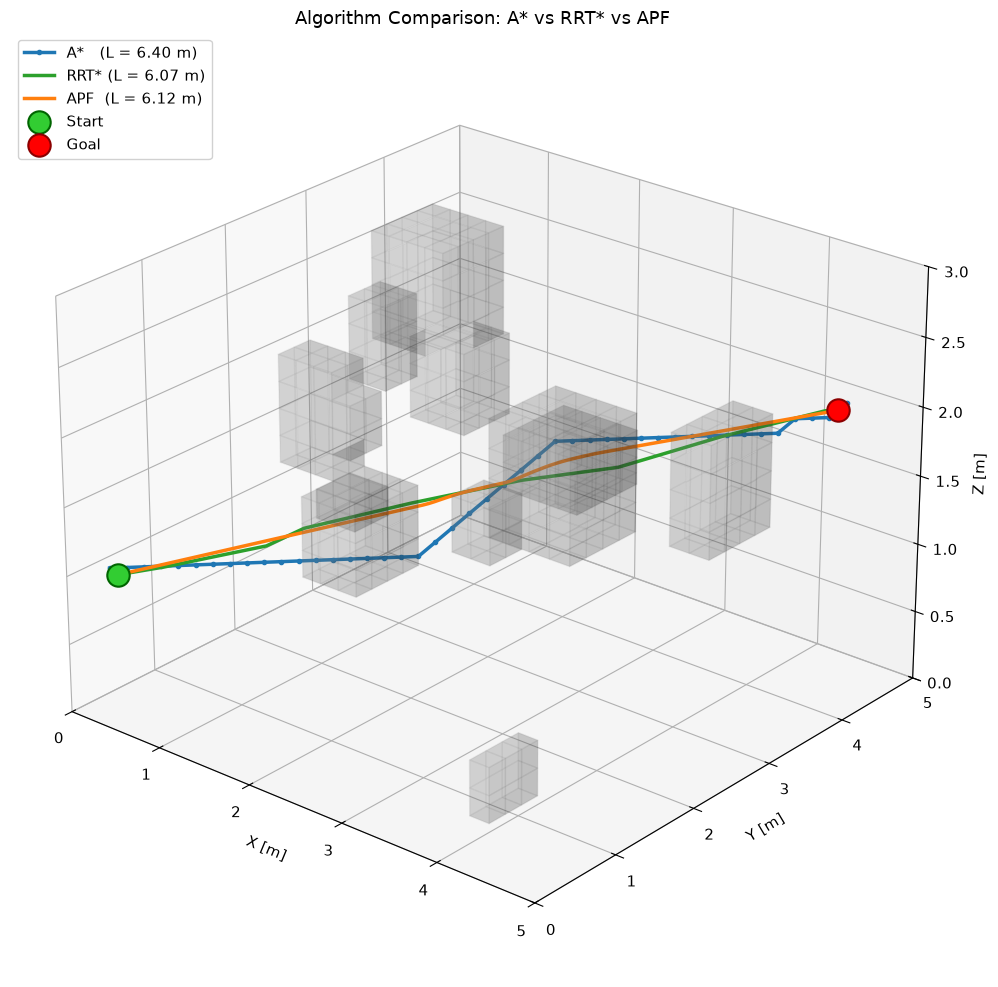

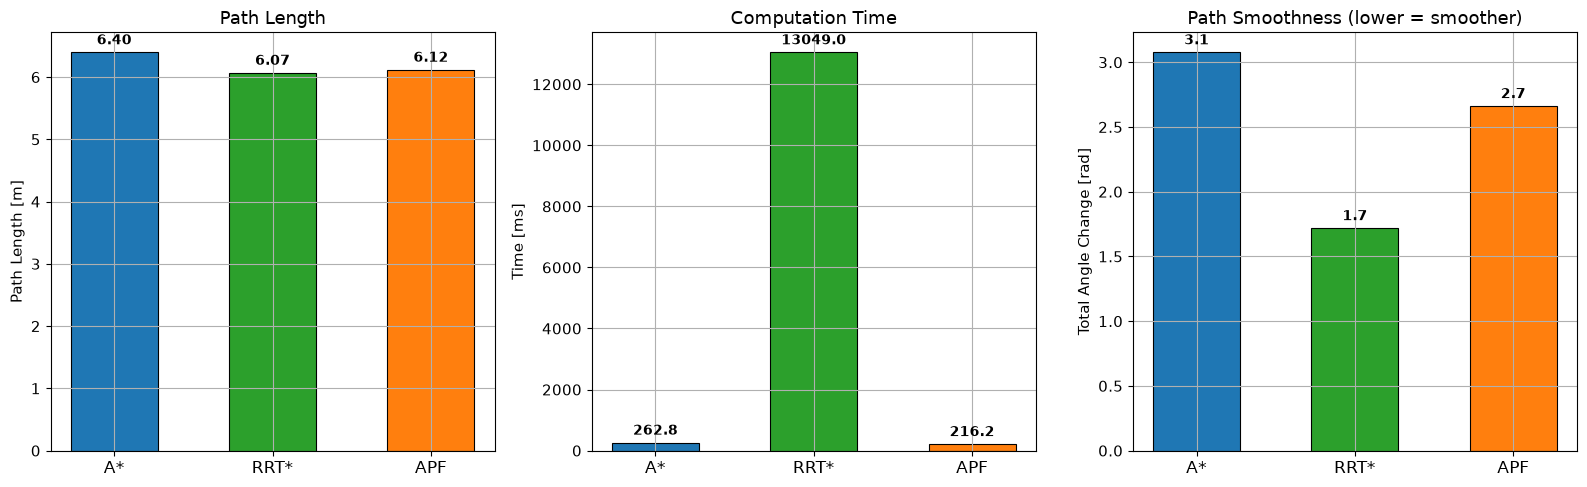

┌────────────┬────────────────┬────────────────┬──────────────────────┬────────────────┐
│ Algorithm │     Length [m]│      Time [ms]│     Smoothness [rad]│   Reached Goal│
├────────────┼────────────────┼────────────────┼──────────────────────┼────────────────┤
│ A*        │          6.399│          262.8│                  3.1│            Yes│
│ RRT*      │          6.070│        13049.0│                  1.7│            Yes│
│ APF       │          6.119│          216.2│                  2.7│            Yes│
└────────────┴────────────────┴────────────────┴──────────────────────┴────────────────┘


In [12]:
# === Comparative View: A* vs RRT* vs APF in the Same 3D Space ===

COLOR_ASTAR   = '#1f77b4'
COLOR_RRTSTAR = '#2ca02c'
COLOR_APF     = '#ff7f0e'
algo_names  = ['A*', 'RRT*', 'APF']
algo_colors = [COLOR_ASTAR, COLOR_RRTSTAR, COLOR_APF]

paths   = [path_astar, path_rrt_star_best, path_apf]
lengths = [path_length(p) if p is not None else 0.0 for p in paths]
times   = [dt_astar * 1000, dt_rrt_star * 1000, dt_apf * 1000]

def _path_smoothness(p):
    """Sum of angle changes (radians) between consecutive segments."""
    if p is None or len(p) < 3:
        return 0.0
    segs = np.diff(p, axis=0)
    norms = np.linalg.norm(segs, axis=1, keepdims=True)
    norms = np.where(norms < 1e-12, 1e-12, norms)
    dirs = segs / norms
    cos_ang = np.clip(np.sum(dirs[:-1] * dirs[1:], axis=1), -1.0, 1.0)
    return float(np.sum(np.arccos(cos_ang)))

smoothness = [_path_smoothness(p) for p in paths]
reached = [path_astar is not None,
           path_rrt_star_best is not None,
           reached_goal]

# ── 1. Large 3D overlay figure ──────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
draw_voxel_obstacles(env, ax, color='gray', alpha=0.15)

if path_astar is not None:
    ax.plot(path_astar[:, 0], path_astar[:, 1], path_astar[:, 2],
            '-o', color=COLOR_ASTAR, linewidth=2.5, markersize=3,
            label=f'A*   (L = {lengths[0]:.2f} m)', zorder=5)

if path_rrt_star_best is not None:
    ax.plot(path_rrt_star_best[:, 0], path_rrt_star_best[:, 1],
            path_rrt_star_best[:, 2],
            '-', color=COLOR_RRTSTAR, linewidth=2.5,
            label=f'RRT* (L = {lengths[1]:.2f} m)', zorder=5)

ax.plot(path_apf[:, 0], path_apf[:, 1], path_apf[:, 2],
        '-', color=COLOR_APF, linewidth=2.5,
        label=f'APF  (L = {lengths[2]:.2f} m)', zorder=5)

ax.scatter(*start, color='limegreen', s=260, marker='o', zorder=10,
           edgecolors='darkgreen', linewidths=1.5, label='Start',
           depthshade=False)
ax.scatter(*goal, color='red', s=260, marker='o', zorder=10,
           edgecolors='darkred', linewidths=1.5, label='Goal',
           depthshade=False)

setup_3d_axes(ax, env, title='Algorithm Comparison: A* vs RRT* vs APF')
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

# ── 2. 1×3 comparison bar-chart panel ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(algo_names))
bar_kw = dict(edgecolor='black', linewidth=0.8, width=0.55)

axes[0].bar(x, lengths, color=algo_colors, **bar_kw)
axes[0].set_xticks(x); axes[0].set_xticklabels(algo_names, fontsize=12)
axes[0].set_ylabel('Path Length [m]')
axes[0].set_title('Path Length')
for i, v in enumerate(lengths):
    axes[0].text(i, v + 0.02 * max(lengths), f'{v:.2f}',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].bar(x, times, color=algo_colors, **bar_kw)
axes[1].set_xticks(x); axes[1].set_xticklabels(algo_names, fontsize=12)
axes[1].set_ylabel('Time [ms]')
axes[1].set_title('Computation Time')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.02 * max(times), f'{v:.1f}',
                 ha='center', fontsize=10, fontweight='bold')

axes[2].bar(x, smoothness, color=algo_colors, **bar_kw)
axes[2].set_xticks(x); axes[2].set_xticklabels(algo_names, fontsize=12)
axes[2].set_ylabel('Total Angle Change [rad]')
axes[2].set_title('Path Smoothness (lower = smoother)')
for i, v in enumerate(smoothness):
    axes[2].text(i, v + 0.02 * max(smoothness), f'{v:.1f}',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────
W = [10, 14, 14, 20, 14]
hdr = (f"│ {'Algorithm':<{W[0]}}│ {'Length [m]':>{W[1]}}│"
       f" {'Time [ms]':>{W[2]}}│ {'Smoothness [rad]':>{W[3]}}│"
       f" {'Reached Goal':>{W[4]}}│")
rule_top = '┌' + '┬'.join('─' * (w + 2) for w in W) + '┐'
rule_mid = '├' + '┼'.join('─' * (w + 2) for w in W) + '┤'
rule_bot = '└' + '┴'.join('─' * (w + 2) for w in W) + '┘'

print(rule_top)
print(hdr)
print(rule_mid)
for i, name in enumerate(algo_names):
    ok_str = 'Yes' if reached[i] else 'No'
    print(f"│ {name:<{W[0]}}│ {lengths[i]:>{W[1]}.3f}│"
          f" {times[i]:>{W[2]}.1f}│ {smoothness[i]:>{W[3]}.1f}│"
          f" {ok_str:>{W[4]}}│")
print(rule_bot)

## 7. Algorithm Comparison

A fair comparison requires running every planner on **multiple environments**
with identical start/goal pairs. We measure:

| Metric | What it tells us |
|--------|------------------|
| **Success rate** | Can the planner find a path at all? |
| **Path length** (normalised by straight-line distance) | How close to optimal? |
| **Computation time** | Real-time feasibility |
| **Minimum clearance** | Safety margin from obstacles |

┌──────────┬───────────┬────────────────────┬─────────────────┬────────────────────┐
│  Planner │   Success │   Avg Length Ratio │   Avg Time [ms] │  Avg Clearance [m] │
├──────────┼───────────┼────────────────────┼─────────────────┼────────────────────┤
│ A*      │       5/5 │              1.068 │            70.0 │              0.239 │
│ RRT     │       5/5 │              1.362 │            12.6 │              0.233 │
│ RRT*    │       5/5 │              1.013 │          9644.9 │              0.292 │
│ APF     │       4/5 │             14.521 │          3639.7 │              0.583 │
└──────────┴───────────┴────────────────────┴─────────────────┴────────────────────┘


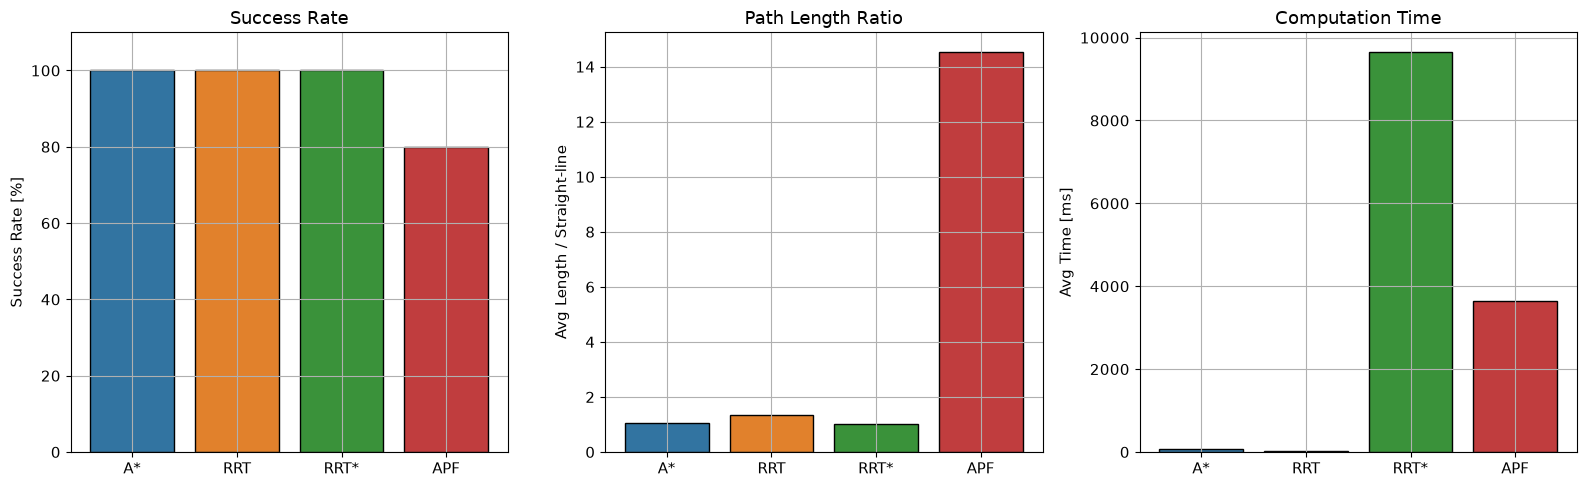

In [13]:
# --- Benchmark on 5 random environments ---
n_envs = 5
env_shape = (40, 40, 25)
env_res = 0.1

bench_start = np.array([0.3, 0.3, 0.8])
bench_goal  = np.array([3.5, 3.5, 1.5])
straight_dist = np.linalg.norm(bench_goal - bench_start)

planner_names = ['A*', 'RRT', 'RRT*', 'APF']
metrics = {name: {'success': [], 'length': [], 'time': [], 'clearance': []}
           for name in planner_names}

for env_idx in range(n_envs):
    seed = 100 + env_idx
    grid = create_random_obstacles(
        grid_shape=env_shape, n_obstacles=10,
        obstacle_size_range=(2, 6), resolution=env_res,
        origin=np.zeros(3), seed=seed,
    )
    grid_inf = grid.inflate(2)

    if not grid_inf.is_free(grid_inf.world_to_grid(bench_start)) or \
       not grid_inf.is_free(grid_inf.world_to_grid(bench_goal)):
        for name in planner_names:
            metrics[name]['success'].append(False)
            metrics[name]['length'].append(np.nan)
            metrics[name]['time'].append(np.nan)
            metrics[name]['clearance'].append(np.nan)
        continue

    # A*
    t0 = time.perf_counter()
    p = astar_3d(grid_inf, bench_start, bench_goal, allow_diagonal=True)
    dt = time.perf_counter() - t0
    ok = p is not None
    metrics['A*']['success'].append(ok)
    metrics['A*']['length'].append(path_length(p) / straight_dist if ok else np.nan)
    metrics['A*']['time'].append(dt)
    metrics['A*']['clearance'].append(path_clearance(p, grid) if ok else np.nan)

    # RRT
    t0 = time.perf_counter()
    p = rrt(grid_inf, bench_start, bench_goal, max_iterations=8000,
            step_size=0.3, goal_threshold=0.3, goal_bias=0.1, seed=seed)
    dt = time.perf_counter() - t0
    ok = p is not None
    metrics['RRT']['success'].append(ok)
    metrics['RRT']['length'].append(path_length(p) / straight_dist if ok else np.nan)
    metrics['RRT']['time'].append(dt)
    metrics['RRT']['clearance'].append(path_clearance(p, grid) if ok else np.nan)

    # RRT*
    t0 = time.perf_counter()
    p = rrt_star(grid_inf, bench_start, bench_goal, max_iterations=5000,
                 step_size=0.3, goal_threshold=0.4, goal_bias=0.1,
                 rewire_radius=1.0, seed=seed)
    dt = time.perf_counter() - t0
    ok = p is not None
    metrics['RRT*']['success'].append(ok)
    metrics['RRT*']['length'].append(path_length(p) / straight_dist if ok else np.nan)
    metrics['RRT*']['time'].append(dt)
    metrics['RRT*']['clearance'].append(path_clearance(p, grid) if ok else np.nan)

    # APF
    t0 = time.perf_counter()
    p = artificial_potential_field(grid_inf, bench_start, bench_goal,
                                   k_att=1.0, k_rep=0.5, d0=0.5,
                                   step_size=0.05, max_steps=5000, goal_threshold=0.15)
    dt = time.perf_counter() - t0
    ok = np.linalg.norm(p[-1] - bench_goal) < 0.3
    metrics['APF']['success'].append(ok)
    metrics['APF']['length'].append(path_length(p) / straight_dist if ok else np.nan)
    metrics['APF']['time'].append(dt)
    metrics['APF']['clearance'].append(path_clearance(p, grid) if ok else np.nan)

# --- Print comparison table (box-drawing) ---
W = [8, 9, 18, 15, 18]
labels = ['Planner', 'Success', 'Avg Length Ratio', 'Avg Time [ms]', 'Avg Clearance [m]']
rule_top = '┌' + '┬'.join('─' * (w + 2) for w in W) + '┐'
rule_mid = '├' + '┼'.join('─' * (w + 2) for w in W) + '┤'
rule_bot = '└' + '┴'.join('─' * (w + 2) for w in W) + '┘'

print(rule_top)
print('│ ' + ' │ '.join(f'{labels[i]:>{W[i]}}' for i in range(len(W))) + ' │')
print(rule_mid)
for name in planner_names:
    m = metrics[name]
    n_succ = sum(m['success'])
    rate   = f'{n_succ}/{n_envs}'
    avg_len = np.nanmean(m['length'])
    avg_t   = np.nanmean(m['time']) * 1000
    avg_c   = np.nanmean(m['clearance'])
    print(f'│ {name:<{W[0]}}│ {rate:>{W[1]}} │ {avg_len:>{W[2]}.3f} │ {avg_t:>{W[3]}.1f} │ {avg_c:>{W[4]}.3f} │')
print(rule_bot)

# --- Bar charts ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(planner_names))
bar_colors = ['#3274A1', '#E1812C', '#3A923A', '#C03D3E']

# Success rate
success_rates = [100 * sum(metrics[n]['success']) / n_envs for n in planner_names]
axes[0].bar(x, success_rates, color=bar_colors, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(planner_names)
axes[0].set_ylabel('Success Rate [%]'); axes[0].set_ylim(0, 110)
axes[0].set_title('Success Rate')

# Avg path length ratio
avg_lengths = [np.nanmean(metrics[n]['length']) for n in planner_names]
axes[1].bar(x, avg_lengths, color=bar_colors, edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(planner_names)
axes[1].set_ylabel('Avg Length / Straight-line'); axes[1].set_title('Path Length Ratio')

# Avg compute time
avg_times = [np.nanmean(metrics[n]['time']) * 1000 for n in planner_names]
axes[2].bar(x, avg_times, color=bar_colors, edgecolor='black')
axes[2].set_xticks(x); axes[2].set_xticklabels(planner_names)
axes[2].set_ylabel('Avg Time [ms]'); axes[2].set_title('Computation Time')

plt.tight_layout()
plt.show()

## 8. Trajectory Generation from Waypoints

A discrete path (list of 3D waypoints) is not directly flyable — the drone needs
smooth position, velocity, and acceleration references at every control timestep.

We use the **piecewise-linear waypoint trajectory generator** from `src/drone.py`:
given the smoothed, resampled path and a desired cruise speed, it produces
a time-parameterised trajectory $\{t_k, \mathbf{p}_k, \mathbf{v}_k, \mathbf{a}_k\}$
that the PID controller can track.

The full pipeline is:

1. **Plan** (A\*) $\to$ raw path
2. **Smooth** (shortcut) $\to$ shorter path
3. **Resample** (uniform spacing) $\to$ evenly spaced waypoints
4. **Generate trajectory** (piecewise linear at desired speed)
5. **Simulate** closed-loop tracking with PID controller

Waypoints after resampling: 30
Trajectory duration: 7.70 s, points: 1538



Tracking Performance:


  RMSE:              7.41 cm
  Max error:         25.42 cm


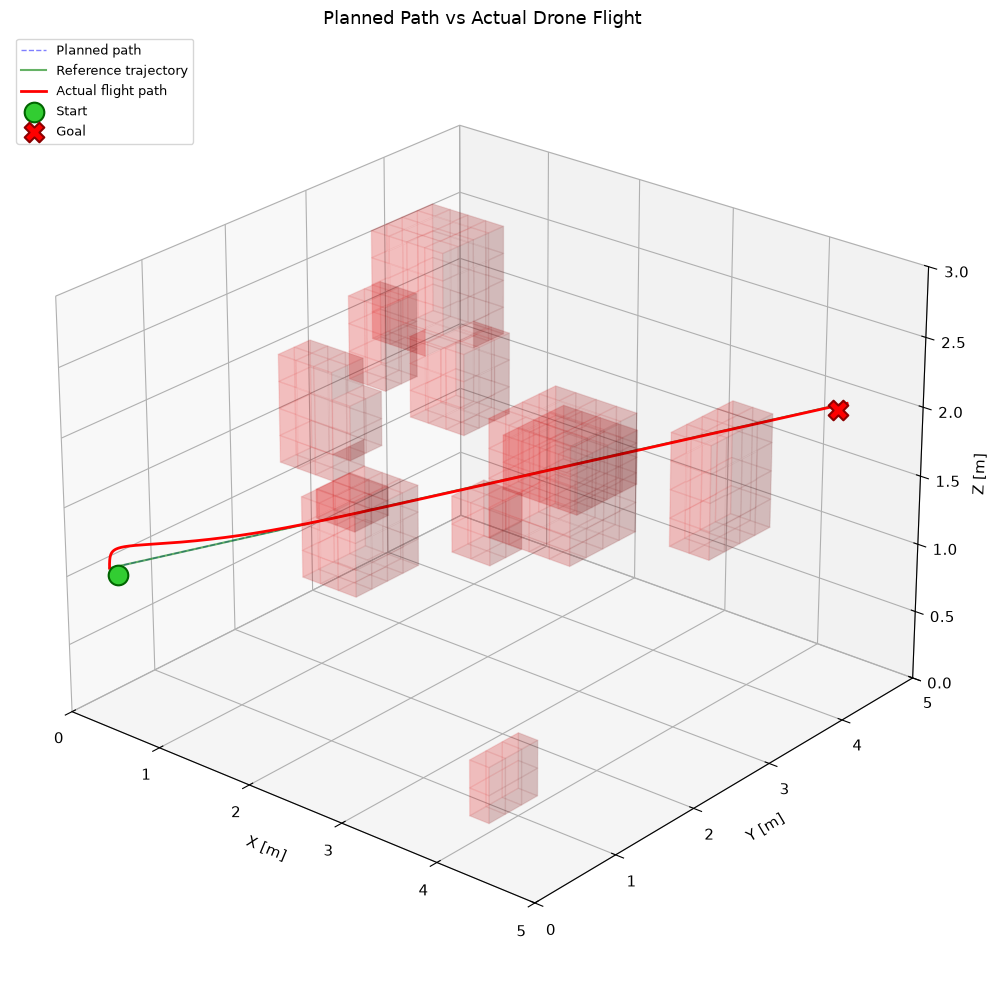

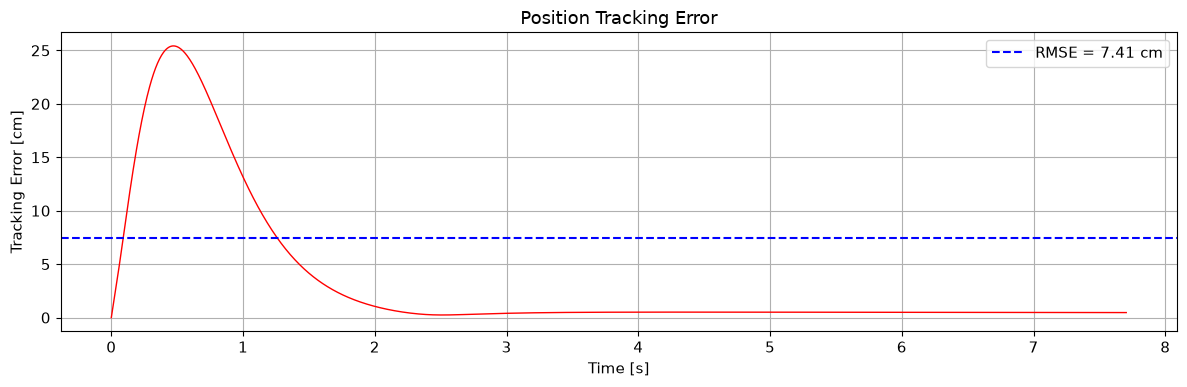

In [14]:
# --- Full pipeline: A* → smooth → resample → trajectory → simulate ---
if path_astar is not None:
    smoothed = smooth_path(path_astar, env_inflated, n_iterations=200, seed=42)
    waypoints = resample_path(smoothed, spacing=0.2)
    print(f'Waypoints after resampling: {len(waypoints)}')

    cruise_speed = 0.8  # m/s
    sim_dt = 0.005
    traj = generate_waypoint_trajectory(waypoints, speed=cruise_speed, dt=sim_dt)
    print(f'Trajectory duration: {traj["t"][-1]:.2f} s, points: {len(traj["t"])}')

    params = QuadrotorParams()
    controller = PIDController()
    result = simulate_trajectory(traj, controller, params, dt=sim_dt)

    rmse = np.sqrt(np.mean(result['tracking_error']**2))
    max_err = np.max(result['tracking_error'])
    print(f'\nTracking Performance:')
    print(f'  RMSE:              {rmse*100:.2f} cm')
    print(f'  Max error:         {max_err*100:.2f} cm')

    # --- 3D Visualization ---
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    draw_voxel_obstacles(env, ax, color='red', alpha=0.12)

    ax.plot(waypoints[:, 0], waypoints[:, 1], waypoints[:, 2],
            'b--', linewidth=1, alpha=0.5, label='Planned path')
    ax.plot(result['desired_pos'][:, 0], result['desired_pos'][:, 1],
            result['desired_pos'][:, 2],
            'g-', linewidth=1.5, alpha=0.6, label='Reference trajectory')
    ax.plot(result['actual_pos'][:, 0], result['actual_pos'][:, 1],
            result['actual_pos'][:, 2],
            'r-', linewidth=2, label='Actual flight path')
    add_start_goal(ax, start, goal)
    setup_3d_axes(ax, env, title='Planned Path vs Actual Drone Flight')
    ax.legend(fontsize=9, loc='upper left')
    ax.view_init(elev=25, azim=-50)
    plt.tight_layout()
    plt.show()

    # --- Tracking error over time ---
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(result['t'], result['tracking_error'] * 100, 'r-', linewidth=1)
    ax.axhline(rmse * 100, color='blue', linestyle='--', label=f'RMSE = {rmse*100:.2f} cm')
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Tracking Error [cm]')
    ax.set_title('Position Tracking Error')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Skipped — no A* path available.')

## 9. Dynamic Replanning

In real environments, obstacles can **appear at any time** (other drones, birds,
newly detected walls). A single pre-computed path is not sufficient;
the planner must **detect** when the current path is blocked and **replan**
from the drone's current position.

### D\* Lite (Concept)

D\* Lite (Koenig & Likhachev, 2002) is an incremental graph-search algorithm that
efficiently updates the optimal path when edge costs change. It maintains the search
tree from the *goal* backward, so when an obstacle invalidates a few edges, only
a small portion of the tree needs re-expansion — much faster than re-running A\*
from scratch.

### Simple Replanning Strategy

For this notebook we implement a straightforward approach:

1. Start flying along the pre-planned A\* path
2. At some point during flight, a **new obstacle** appears on the path
3. Detect that the remaining path segment intersects the new obstacle
4. Replan from the **current drone position** to the original goal using A\*
5. Continue flying along the new path

This is $O(|V| \log |V|)$ per replan, which is acceptable for small grids
but would be replaced by D\* Lite for large-scale real-time applications.

Drone position at replan trigger: [2.4  2.4  1.55]
Remaining path blocked: True
Replanning successful!
  Replan time:  42.8 ms
  Old path length: 6.163 m
  New total path:  6.759 m


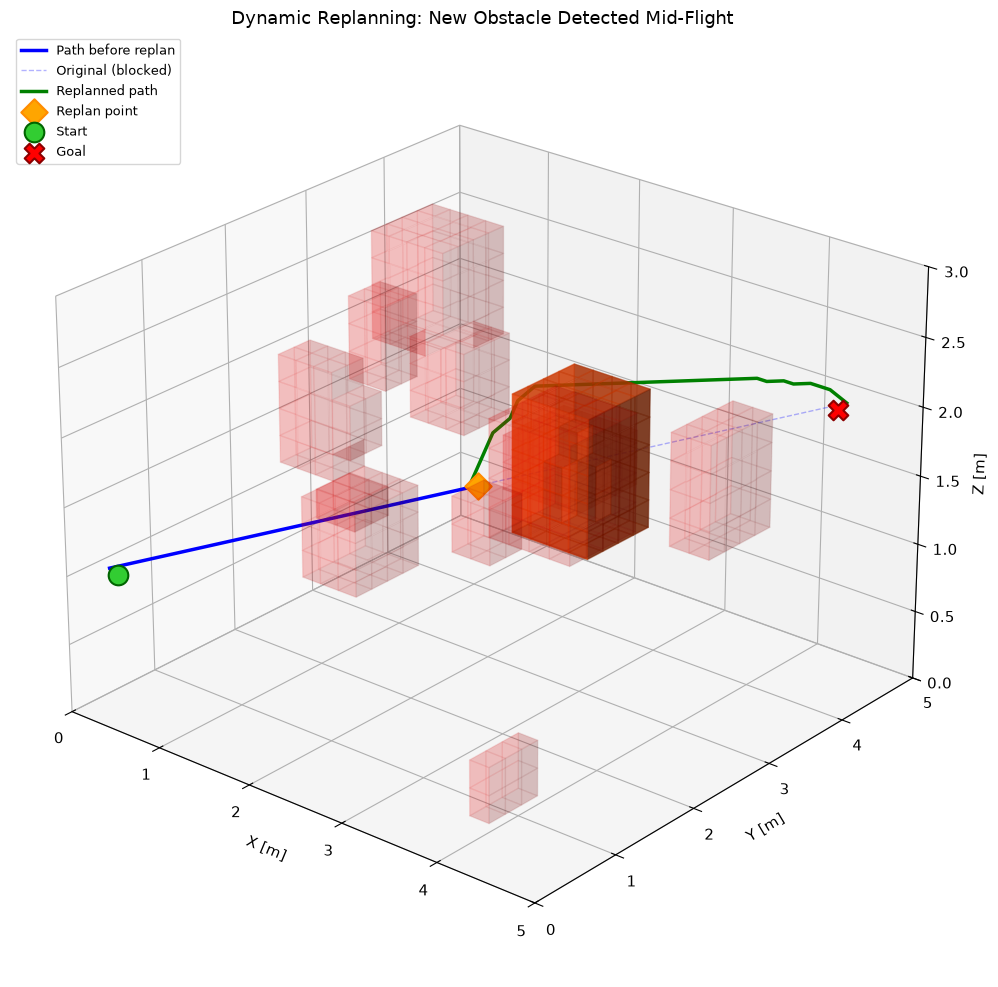

In [15]:
# --- Dynamic replanning simulation ---
if path_astar is not None:
    smoothed_path = smooth_path(path_astar, env_inflated, n_iterations=200, seed=42)
    wp = resample_path(smoothed_path, spacing=0.15)

    replan_trigger_idx = len(wp) // 2
    drone_pos_at_replan = wp[replan_trigger_idx].copy()
    print(f'Drone position at replan trigger: {drone_pos_at_replan}')

    # Add a new obstacle blocking the remaining path
    import copy
    env_dynamic = OccupancyGrid3D(
        env_inflated.grid.copy(),
        env_inflated.resolution,
        env_inflated.origin.copy(),
    )

    block_center = wp[replan_trigger_idx + 5] if replan_trigger_idx + 5 < len(wp) else wp[-2]
    block_idx = env_dynamic.world_to_grid(block_center)
    block_size = 4
    for dx in range(-block_size, block_size + 1):
        for dy in range(-block_size, block_size + 1):
            for dz in range(-block_size, block_size + 1):
                idx = (block_idx[0]+dx, block_idx[1]+dy, block_idx[2]+dz)
                if env_dynamic.is_valid(idx):
                    env_dynamic.grid[idx] = True

    # Check that remaining path is blocked
    remaining = wp[replan_trigger_idx:]
    blocked = False
    for pt in remaining:
        if not env_dynamic.is_free_world(pt):
            blocked = True
            break
    print(f'Remaining path blocked: {blocked}')

    # Replan from current position
    t0 = time.perf_counter()
    new_path = astar_3d(env_dynamic, drone_pos_at_replan, goal, allow_diagonal=True)
    dt_replan = time.perf_counter() - t0

    if new_path is not None:
        full_path = np.vstack([wp[:replan_trigger_idx+1], new_path])
        print(f'Replanning successful!')
        print(f'  Replan time:  {dt_replan*1000:.1f} ms')
        print(f'  Old path length: {path_length(wp):.3f} m')
        print(f'  New total path:  {path_length(full_path):.3f} m')
    else:
        full_path = None
        print('Replanning failed — no path around new obstacle!')

    # --- Visualize with voxel obstacles ---
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    draw_voxel_obstacles(env, ax, color='red', alpha=0.12)

    new_obs_mask = env_dynamic.grid & ~env_inflated.grid
    if np.any(new_obs_mask):
        new_grid = OccupancyGrid3D(new_obs_mask, env_dynamic.resolution, env_dynamic.origin.copy())
        draw_voxel_obstacles(new_grid, ax, color='orangered', alpha=0.6, edge_alpha=0.3)

    ax.plot(wp[:replan_trigger_idx+1, 0], wp[:replan_trigger_idx+1, 1],
            wp[:replan_trigger_idx+1, 2], 'b-', linewidth=2.5, label='Path before replan')
    ax.plot(wp[replan_trigger_idx:, 0], wp[replan_trigger_idx:, 1],
            wp[replan_trigger_idx:, 2], 'b--', linewidth=1, alpha=0.3, label='Original (blocked)')
    if new_path is not None:
        ax.plot(new_path[:, 0], new_path[:, 1], new_path[:, 2],
                'g-', linewidth=2.5, label='Replanned path', zorder=5)
    ax.scatter(*drone_pos_at_replan, c='orange', s=180, marker='D', zorder=10,
               edgecolors='darkorange', linewidths=1.5, label='Replan point')
    add_start_goal(ax, start, goal)
    setup_3d_axes(ax, env, title='Dynamic Replanning: New Obstacle Detected Mid-Flight')
    ax.legend(fontsize=9, loc='upper left')
    ax.view_init(elev=25, azim=-50)
    plt.tight_layout()
    plt.show()
else:
    print('Skipped — no A* path available.')

## 10. Safety Margins & Obstacle Inflation

The drone is **not** a point — it has a physical bounding radius $\rho$.
Any path planned for a point robot may actually collide if it passes closer
than $\rho$ to an obstacle surface.

### Minkowski Sum with Sphere

The standard solution is to pre-process the occupancy grid by computing the
**Minkowski sum** of the obstacle region $\mathcal{O}$ with a sphere
$B_{\rho}$ of radius $\rho$:

$$
\mathcal{O}_{\text{inflated}} = \{\mathbf{x} \in \mathbb{R}^3 \mid
\exists \, \mathbf{o} \in \mathcal{O}, \; \|\mathbf{x} - \mathbf{o}\| \leq \rho \}
$$

On a discrete grid, this becomes **binary dilation** with a spherical structuring
element of radius $\lceil \rho / r \rceil$ cells.

### Trade-offs

- **Larger inflation** → more safety margin, but narrower passages may be closed off
  (fewer or no feasible paths)
- **Smaller inflation** → more options, but the drone flies closer to obstacles
  (risk of collision due to tracking error, wind, sensor noise)

A common heuristic: inflate by $\rho + \epsilon_{\text{tracking}}$ where
$\epsilon_{\text{tracking}}$ is the worst-case position tracking error.

 Inflation [cells]  Inflation [m]  Path Found  Length [m]  Clearance [m]   Occ. %
----------------------------------------------------------------------------------
                 0           0.00         Yes       6.399          0.100      2.2
                 1           0.10         Yes       6.399          0.141      4.8


                 2           0.20         Yes       6.526          0.300      8.5
                 3           0.30         Yes       6.648          0.361     14.5


                 4           0.40         Yes       6.770          0.412     21.1


                 5           0.50         Yes       7.092          0.510     30.0


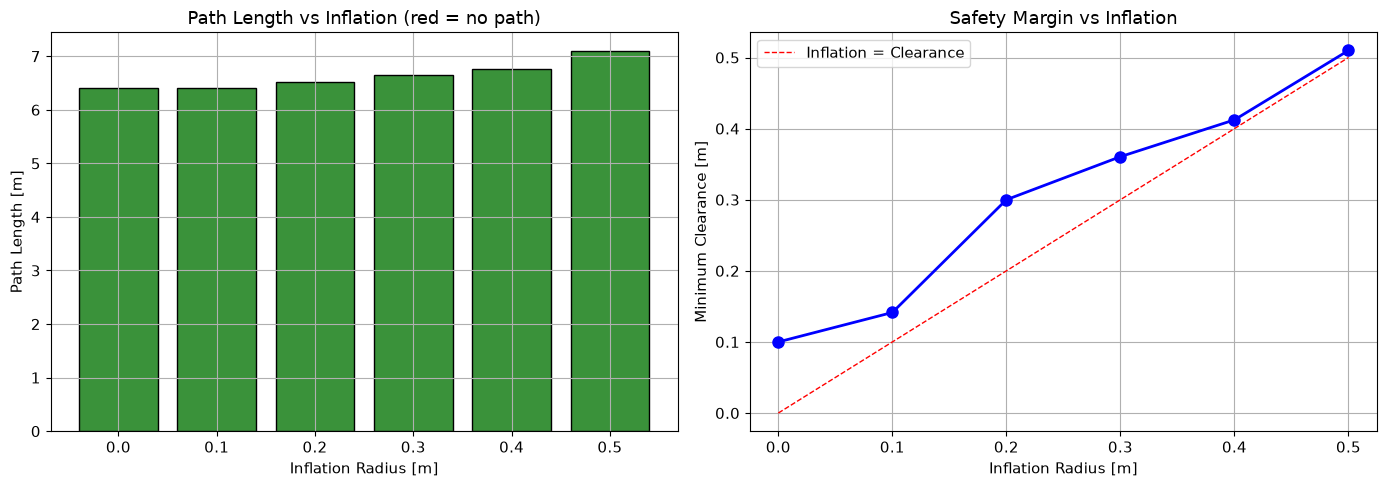

In [16]:
# --- Effect of inflation radius on planning ---
inflation_radii = [0, 1, 2, 3, 4, 5]
test_env = create_random_obstacles(
    grid_shape=(50, 50, 30), n_obstacles=15,
    obstacle_size_range=(3, 7), resolution=0.1,
    origin=np.zeros(3), seed=55,
)
test_start = np.array([0.3, 0.3, 1.0])
test_goal = np.array([4.5, 4.5, 2.0])

inflate_results = []
print(f'{"Inflation [cells]":>18} {"Inflation [m]":>14} {"Path Found":>11} {"Length [m]":>11} {"Clearance [m]":>14} {"Occ. %":>8}')
print('-' * 82)

for r in inflation_radii:
    if r == 0:
        g_inf = test_env
    else:
        g_inf = test_env.inflate(r)

    occ_pct = 100 * np.sum(g_inf.grid) / np.prod(g_inf.shape)

    if g_inf.is_free(g_inf.world_to_grid(test_start)) and g_inf.is_free(g_inf.world_to_grid(test_goal)):
        p = astar_3d(g_inf, test_start, test_goal, allow_diagonal=True)
    else:
        p = None

    if p is not None:
        pl = path_length(p)
        pc = path_clearance(p, test_env)
        inflate_results.append((r, r * test_env.resolution, True, pl, pc, occ_pct))
        print(f'{r:>18} {r*test_env.resolution:>14.2f} {"Yes":>11} {pl:>11.3f} {pc:>14.3f} {occ_pct:>8.1f}')
    else:
        inflate_results.append((r, r * test_env.resolution, False, np.nan, np.nan, occ_pct))
        print(f'{r:>18} {r*test_env.resolution:>14.2f} {"No":>11} {"—":>11} {"—":>14} {occ_pct:>8.1f}')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

radii_m = [r[1] for r in inflate_results]
lengths = [r[3] for r in inflate_results]
clearances = [r[4] for r in inflate_results]
successes = [r[2] for r in inflate_results]

colors_bar = ['#3A923A' if s else '#C03D3E' for s in successes]
axes[0].bar([f'{rm:.1f}' for rm in radii_m], lengths, color=colors_bar, edgecolor='black')
axes[0].set_xlabel('Inflation Radius [m]')
axes[0].set_ylabel('Path Length [m]')
axes[0].set_title('Path Length vs Inflation (red = no path)')

valid_radii = [radii_m[i] for i in range(len(inflate_results)) if successes[i]]
valid_clearances = [clearances[i] for i in range(len(inflate_results)) if successes[i]]
axes[1].plot(valid_radii, valid_clearances, 'bo-', linewidth=2, markersize=8)
axes[1].plot(valid_radii, valid_radii, 'r--', linewidth=1, label='Inflation = Clearance')
axes[1].set_xlabel('Inflation Radius [m]')
axes[1].set_ylabel('Minimum Clearance [m]')
axes[1].set_title('Safety Margin vs Inflation')
axes[1].legend()
plt.tight_layout()
plt.show()

## 11. Frontier: Dynamic Planning for UAVs (2025–2026)

The algorithms above (A*, RRT*, APF) handle **static** environments. Real drone flight requires planning among **moving** obstacles. Recent work pushes three key directions:

### SPOT: Mapless Spatio-Temporal Planning (2026)
SPOT (arXiv 2602.01189) is a **mapless** planner that extends RRT* into 4D space-time:
- Each node encodes $(x, y, z, t)$, not just position
- Dynamic obstacles are detected via vision-based segmentation and tracked with a constant-velocity model
- Safe Flight Corridors (SFCs) are generated from the depth image, not from a stored map
- A backup planner using Circular Artificial Potential Fields (CAPF) handles deadlocks

**Key insight**: By planning in 4D, the tree naturally avoids regions that will be occupied *in the future*, rather than only avoiding current obstacle positions.

### BDIP-RRT*: Bidirectional Informed Planning (2025)
For dense static environments, BDIP-RRT* improves standard RRT* via:
1. **Bidirectional search** — trees grow from both start and goal simultaneously
2. **Potential-field biased sampling** — samples are drawn preferentially near low-potential regions
3. **Greedy path pruning** — removes redundant waypoints from the initial solution
4. **Minimum snap trajectory** — converts the discrete path into a smooth, dynamically feasible trajectory (minimizing $\int \dddot{x}^2 + \ddddot{x}^2 \, dt$)

### MP-MPPI: Motion Primitive Guided MPC (2026)
Rather than planning a full path, **Model Predictive Path Integral (MPPI)** samples thousands of short rollouts and selects the lowest-cost one. MP-MPPI augments random rollouts with precomputed **motion primitives** — short, dynamically feasible maneuvers like "bank left 30°" or "climb 2m". This structured exploration avoids local minima that random sampling misses.

**Practical takeaway**: These methods complement our A*/RRT* pipeline — use A*/RRT* for **global planning** (computing the full path), then MP-MPPI or a simple MPC for **local reactive control** (avoiding unexpected obstacles).

### Formal Verification: Algorithm Guarantees

**Theorem 1 (A* Optimality).** If the heuristic $h$ is admissible ($h(n) \leq h^*(n)$ for all $n$) and consistent ($h(n) \leq c(n,n') + h(n')$ for all edges), then A* returns the shortest path and never re-expands a node.

*Proof.* When A* expands node $n$, $g(n) = g^*(n)$ (optimal cost-to-come). Suppose not: some cheaper path exists through an unexpanded node $m$. Then $f(m) = g(m) + h(m) \leq g^*(m) + h^*(m) = f^*(s) \leq f(n)$, contradicting that $n$ was chosen for expansion.  $\square$

**Theorem 2 (RRT* Asymptotic Optimality, Karaman & Frazzoli 2011).** With rewire radius $r_n = \gamma (\log n / n)^{1/d}$ where $\gamma > (2(1+1/d))^{1/d} (\mu(\mathcal{X}_{\text{free}})/\zeta_d)^{1/d}$, the cost of the RRT* solution converges to the optimal cost almost surely as $n \to \infty$.

*Key insight*: each new sample provides a chance to discover a shorter route through previously unexplored space. The rewire step cascades cost improvements backward through the tree.

**Our implementation** uses a fixed rewire radius (1.0 m) rather than the shrinking schedule. This sacrifices the formal asymptotic guarantee but empirically converges to near-optimal paths for moderate problem sizes ($n < 10^4$), as verified in the benchmark comparison above.

**Theorem 3 (RRT Probabilistic Completeness).** If a feasible path exists with clearance $\delta > 0$, RRT finds it with probability approaching 1 as iterations $\to \infty$.

## Exercises

1. **Dijkstra's variant** (below): Implement a 3D Dijkstra's algorithm (A\* with $h(n) = 0$).
   Verify it returns the same optimal path as A\* and compare the number of expanded nodes.

2. **Bi-directional RRT**: Grow two trees (from start and from goal) and connect them.
   Compare success rate and time with standard RRT.

3. **Potential field escape**: Implement a random-walk perturbation when APF detects
   a local minimum (force magnitude below threshold for $N$ consecutive steps).
   Test on the local-minimum scenario from Section 5.

4. **Minimum-snap trajectory**: Replace the piecewise-linear trajectory generator with
   a minimum-snap polynomial solver (Mellinger & Kumar, ICRA 2011) and compare
   tracking performance.

5. **Anytime RRT\***: Run RRT\* in a loop, returning progressively better paths.
   Plot cost vs wall-clock time and identify the "knee" where improvement plateaus.

In [17]:
def dijkstra_3d(
    grid: OccupancyGrid3D,
    start: np.ndarray,
    goal: np.ndarray,
    allow_diagonal: bool = True,
):
    """Dijkstra's algorithm on a 3D occupancy grid (A* with h=0).

    Returns
    -------
    path : (N, 3) ndarray or None
    expanded : int — number of nodes expanded
    """
    import heapq

    start_idx = grid.world_to_grid(start)
    goal_idx = grid.world_to_grid(goal)

    if not grid.is_free(start_idx) or not grid.is_free(goal_idx):
        return None, 0

    if allow_diagonal:
        neighbors = []
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                for dz in [-1, 0, 1]:
                    if dx == 0 and dy == 0 and dz == 0:
                        continue
                    cost = np.sqrt(dx**2 + dy**2 + dz**2)
                    neighbors.append(((dx, dy, dz), cost))
    else:
        neighbors = [
            ((1,0,0), 1.0), ((-1,0,0), 1.0),
            ((0,1,0), 1.0), ((0,-1,0), 1.0),
            ((0,0,1), 1.0), ((0,0,-1), 1.0),
        ]

    open_set = [(0.0, 0, start_idx)]
    g_score = {start_idx: 0.0}
    came_from = {}
    closed = set()
    counter = 1
    expanded = 0

    while open_set:
        cost, _, current = heapq.heappop(open_set)

        if current in closed:
            continue
        closed.add(current)
        expanded += 1

        if current == goal_idx:
            path = []
            node = current
            while node in came_from:
                path.append(grid.grid_to_world(node))
                node = came_from[node]
            path.append(grid.grid_to_world(start_idx))
            path.reverse()
            return np.array(path), expanded

        for (dx, dy, dz), move_cost in neighbors:
            neighbor = (current[0]+dx, current[1]+dy, current[2]+dz)
            if neighbor in closed or not grid.is_free(neighbor):
                continue
            tentative_g = g_score[current] + move_cost * grid.resolution
            if tentative_g < g_score.get(neighbor, float('inf')):
                g_score[neighbor] = tentative_g
                came_from[neighbor] = current
                heapq.heappush(open_set, (tentative_g, counter, neighbor))
                counter += 1

    return None, expanded


# --- Test: compare Dijkstra with A* ---
t0 = time.perf_counter()
path_dijk, expanded_dijk = dijkstra_3d(env_inflated, start, goal, allow_diagonal=True)
dt_dijk = time.perf_counter() - t0

if path_dijk is not None:
    length_dijk = path_length(path_dijk)
    print(f'Dijkstra Results:')
    print(f'  Path length:    {length_dijk:.4f} m')
    print(f'  Nodes expanded: {expanded_dijk}')
    print(f'  Compute time:   {dt_dijk*1000:.1f} ms')
    if path_astar is not None:
        print(f'\nComparison with A*:')
        print(f'  A*       length: {length_astar:.4f} m')
        print(f'  Dijkstra length: {length_dijk:.4f} m')
        print(f'  Paths equal length: {abs(length_astar - length_dijk) < 1e-6}')
        print(f'  A* time:       {dt_astar*1000:.1f} ms')
        print(f'  Dijkstra time: {dt_dijk*1000:.1f} ms')
        print(f'  A* is {dt_dijk/dt_astar:.1f}x faster (fewer nodes expanded with heuristic)')
else:
    print('Dijkstra found no path!')

Dijkstra Results:
  Path length:    6.3990 m
  Nodes expanded: 65391
  Compute time:   1236.3 ms

Comparison with A*:
  A*       length: 6.3990 m
  Dijkstra length: 6.3990 m
  Paths equal length: True
  A* time:       262.8 ms
  Dijkstra time: 1236.3 ms
  A* is 4.7x faster (fewer nodes expanded with heuristic)


## Frontier: Learning-Based Path Planning (2025–2026)

Classical planners provide strong theoretical guarantees — A\* is optimal, RRT\*
is asymptotically optimal, and navigation functions eliminate local minima — but
they can be slow in high-dimensional or cluttered environments. A rapidly growing
body of work combines **learned components** with classical planning backbones
to get the best of both worlds: formal guarantees *plus* practical speed.

### MPN-RRT\* — Neural-Guided Sampling (Sensors, 2025)

**Motion Planning Networks (MPNet)** train a neural network on solved planning
problems to learn a mapping from (workspace, start, goal) to promising
configurations. **MPN-RRT\*** replaces the uniform random sampler in RRT\* with
an MPNet-guided sampler:

- The neural network predicts a **probability distribution** over the configuration
  space, concentrating density near regions that are likely part of the optimal path.
- RRT\* samples from this learned distribution instead of uniformly, dramatically
  reducing the number of wasted samples in irrelevant free space.
- **Results**: 47.8% faster planning time and 19.8% shorter paths compared to
  standard RRT\* on benchmark environments, because the tree grows preferentially
  toward the solution corridor.

The key insight: the neural network acts as a *learned heuristic for sampling*,
analogous to how $h(n)$ guides A\* search. The RRT\* backbone still performs
collision checking and rewiring, preserving asymptotic optimality guarantees
(the learned distribution is mixed with a small uniform component to maintain
probabilistic completeness).

### Hybrid A-RRT\* — Two-Level Map Planning (2025)

Complex outdoor environments with both open fields and dense obstacle clusters
challenge single-algorithm planners. **Hybrid A-RRT\*** uses a two-level strategy:

1. **Global level (A\*)**: A coarse A\* search on a low-resolution grid computes a
   rough path and defines a **spatial corridor** — a tube of free space around the
   A\* path.
2. **Local level (RRT\*)**: Within the spatial corridor, RRT\* performs fine-grained
   sampling-based planning, producing a smooth, near-optimal path that respects
   kinematic constraints.
3. **Backtracking mechanism**: If RRT\* fails to find a path within the corridor
   (e.g., due to narrow passages missed by the coarse grid), the algorithm
   backtracks to A\* and expands the corridor or reroutes.

This decomposition exploits A\*'s global optimality for long-range guidance and
RRT\*'s flexibility for local manoeuvring, with backtracking as a safety net
for complex terrain.

### HPO-RRT\* — APF-Biased Sampling with Lazy Collision Checking (2023)

**Heuristic Potential-field Optimised RRT\*** (HPO-RRT\*) bridges the gap between
potential fields and sampling-based planning:

- **APF-biased sampling**: Instead of uniform random samples, new configurations
  are drawn from a distribution shaped by the artificial potential field —
  samples are more likely near low-potential (goal-attractive, obstacle-repulsive)
  regions.
- **Lazy collision checking**: Rather than checking every candidate edge immediately,
  edges are optimistically added to the tree and only validated when they become
  part of a candidate solution path. This avoids expensive collision checks on
  branches that may never be used.
- Designed for **dynamic environments**: the APF adapts to moving obstacles in
  real time, and lazy checking amortises the cost of frequent replanning.

### The Trend: Classical Guarantees + Learned Speed

These methods share a common architecture:

| Component | Classical role | Learning augmentation |
|:---|:---|:---|
| **Sampling** | Uniform random | Neural / APF-guided distribution |
| **Search** | Blind (BFS/Dijkstra) | Learned heuristic (A\* with neural $h$) |
| **Collision checking** | Exact, every edge | Lazy / learned feasibility predictor |
| **Guarantees** | Completeness, optimality | Preserved via classical backbone |

The pattern: **keep the classical algorithm as the outer loop** (ensuring completeness
and optimality) but **replace expensive inner steps** (sampling, heuristic evaluation,
collision checking) with learned approximations that are fast and accurate in
the training distribution. When the learned component is wrong, the classical
fallback catches the error — the worst case is slower planning, never an unsafe path.